# Modflow simulation - Single simulation

In [1]:
import numpy as np
import matplotlib
from matplotlib import colors
import matplotlib.pyplot as plt
import geone
import geone.covModel as gcm
import geone.imgplot3d as imgplt3
import pyvista as pv
import flopy as fp
import sys
import os
from pathlib import Path
import math
import flopy.utils.binaryfile as bf
import flopy.discretization as fgrid
from flopy.utils.gridintersect import GridIntersect
from shapely.geometry import MultiLineString
import copy

# auto reload modules
%load_ext autoreload
%autoreload 2


try:
    import ArchPy
except: # if ArchPy is not installed
    print("ArchPy not installed")
    sys.path.append("C:/Users/Noah/ArchPy/") #Path to the ArchPy file
    import ArchPy
#my modules
from ArchPy.base import *
from ArchPy.tpgs import *

ArchPy not installed


In [2]:
import geopandas as gpd

### Chargement du modèle

In [3]:
#load file
ws = 'ArchPy Model/ArchPy_workspace' #Path to the ArchPy model
modelname = "Versoix_model"
T1 = import_project(modelname, ws=ws)

### IMPORTING PROJECT Versoix_model IN C:/Users/Noah/OneDrive - unine.ch/Documents/Unine/Master Thesis/3. Versoix model/ArchPy Model/ArchPy_workspace DIRECTORY ### 

Unit u12: Surface added for interpolation
Facies a added to unit u12
Facies b added to unit u12
Facies bc added to unit u12
Facies c added to unit u12
Facies d added to unit u12
Unit u14: Surface added for interpolation
Facies Molasse added to unit u14
Unit u3: Surface added for interpolation
Facies Soil added to unit u3
Facies a added to unit u3
Facies ab added to unit u3
Facies b added to unit u3
Facies ac added to unit u3
Facies bc added to unit u3
Facies c added to unit u3
Facies d added to unit u3
Facies e added to unit u3
Unit u7: Surface added for interpolation
Facies a added to unit u7
Facies ab added to unit u7
Facies b added to unit u7
Facies bc added to unit u7
Facies c added to unit u7
Facies d added to unit u7
Facies e added to unit u7
Unit u9: Surface added for interpolation
Facies a added to unit u9
Facies a

In [4]:
import ArchPy.ap_mf
from ArchPy.ap_mf import archpy2modflow, array2cellids

In [5]:
X0 = 2499498 #Model x0 coordinate 
Y0 = 1125350 #Model y0 coordinate 
X1 = 2502460 # 2'962 m
Y1 = 1128167 # 2'817 m

In [6]:
iu = 0

In [7]:
archpy_flow = archpy2modflow(T1, exe_name="Exe_mf6/mf6.exe")  # create the modflow model
archpy_flow.create_sim(grid_mode="layers", iu=iu, unit_limit="u12")

archpy_flow.set_k("K", iu=iu, ifa=0, ip=0, log=True, k_average_method="anisotropic")

Simulation created
To retrieve the simulation, use the get_sim() method


In [8]:
sim = archpy_flow.get_sim()
gwf = archpy_flow.get_gwf()

### Grille

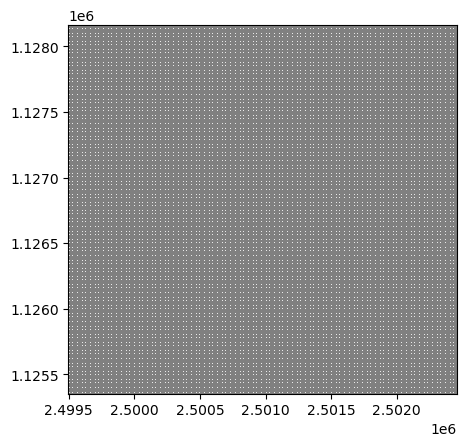

In [9]:
grid = gwf.modelgrid
nrow = grid.nrow
ncol = grid.ncol
nlay = grid.nlay

grid.plot()

In [10]:
ix = GridIntersect(grid, method="vertex", rtree=True)

In [11]:
idomain = grid.idomain

In [12]:
lst_active_cells = []
for ilay in range(nlay):
    for irow in range(nrow):
        for icol in range(ncol):
            if idomain[ilay, irow, icol] == 1:
                lst_active_cells.append((ilay, irow, icol))

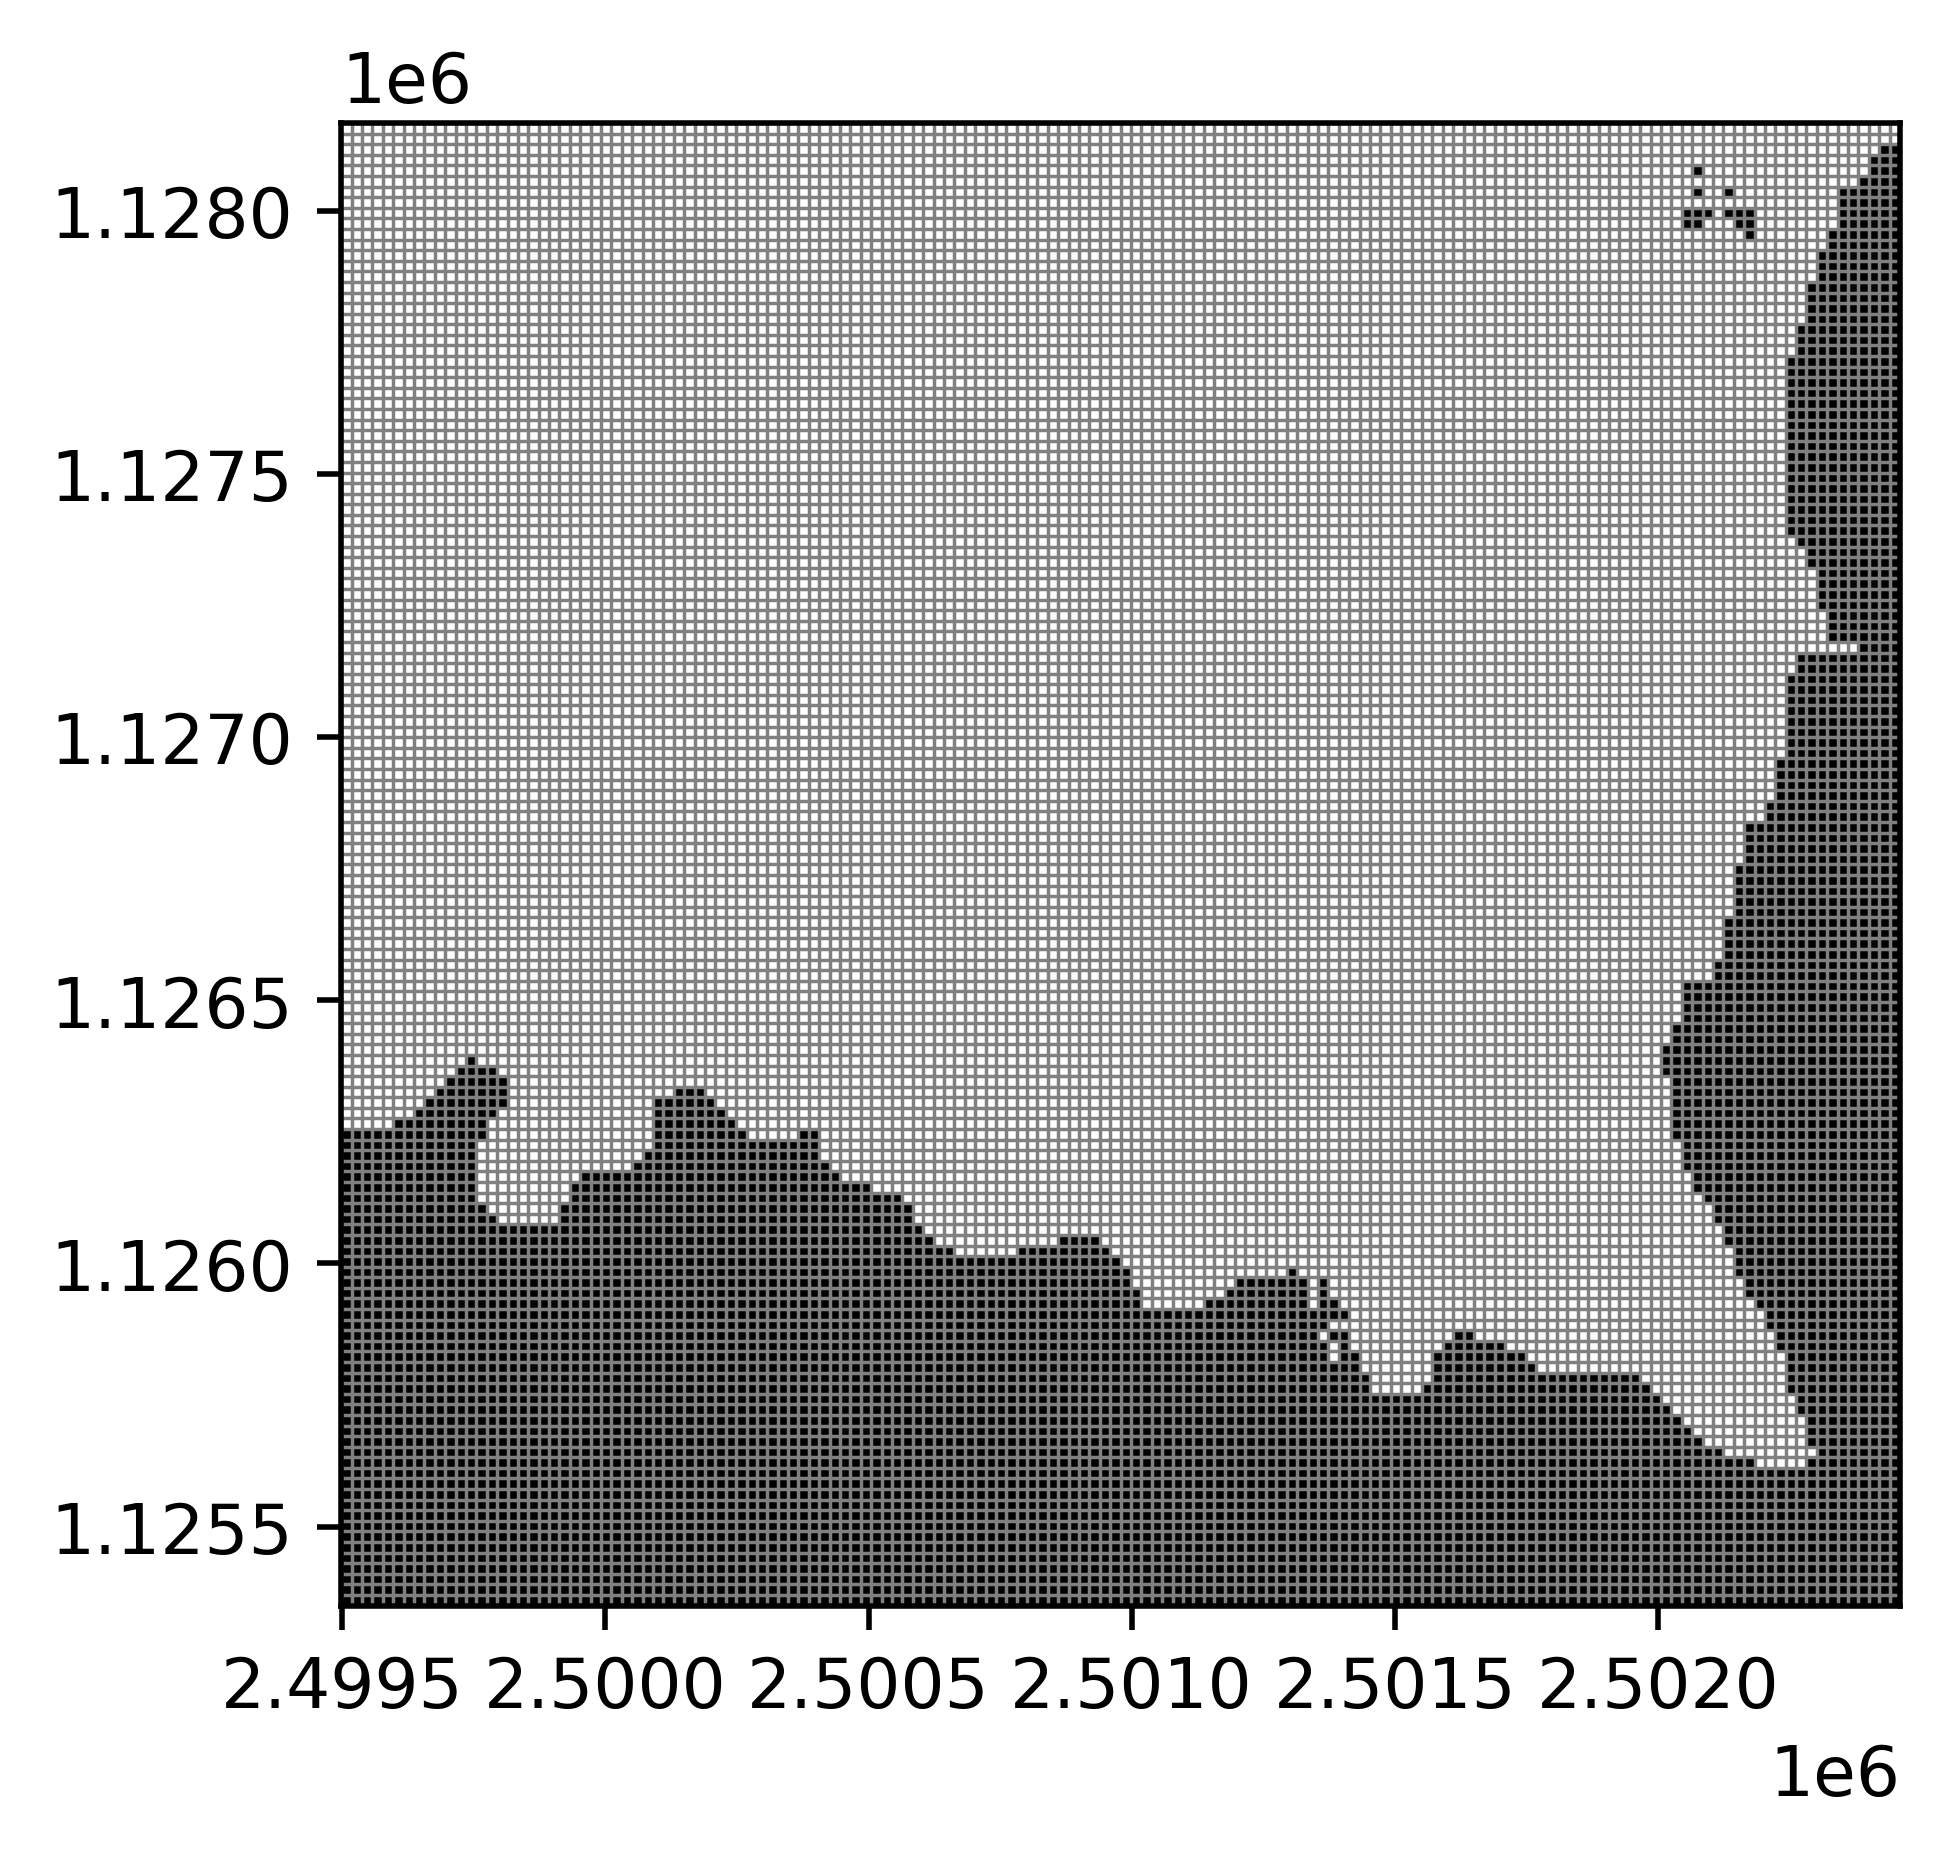

In [13]:
fig = plt.figure(figsize=(4, 4),dpi=500)
ax = fig.add_subplot(1, 1, 1, aspect='equal')
modelmap = fp.plot.PlotMapView(model=gwf, ax=ax, layer=2)
actives = modelmap.plot_ibound(color_vpt="white")
linecollection = modelmap.plot_grid(linewidth=0.5)

fig.tight_layout()

In [14]:
plt.rc('font', size=13) #controls default text size
plt.rc('axes', titlesize=18) #fontsize of the title
plt.rc('axes', labelsize=13) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

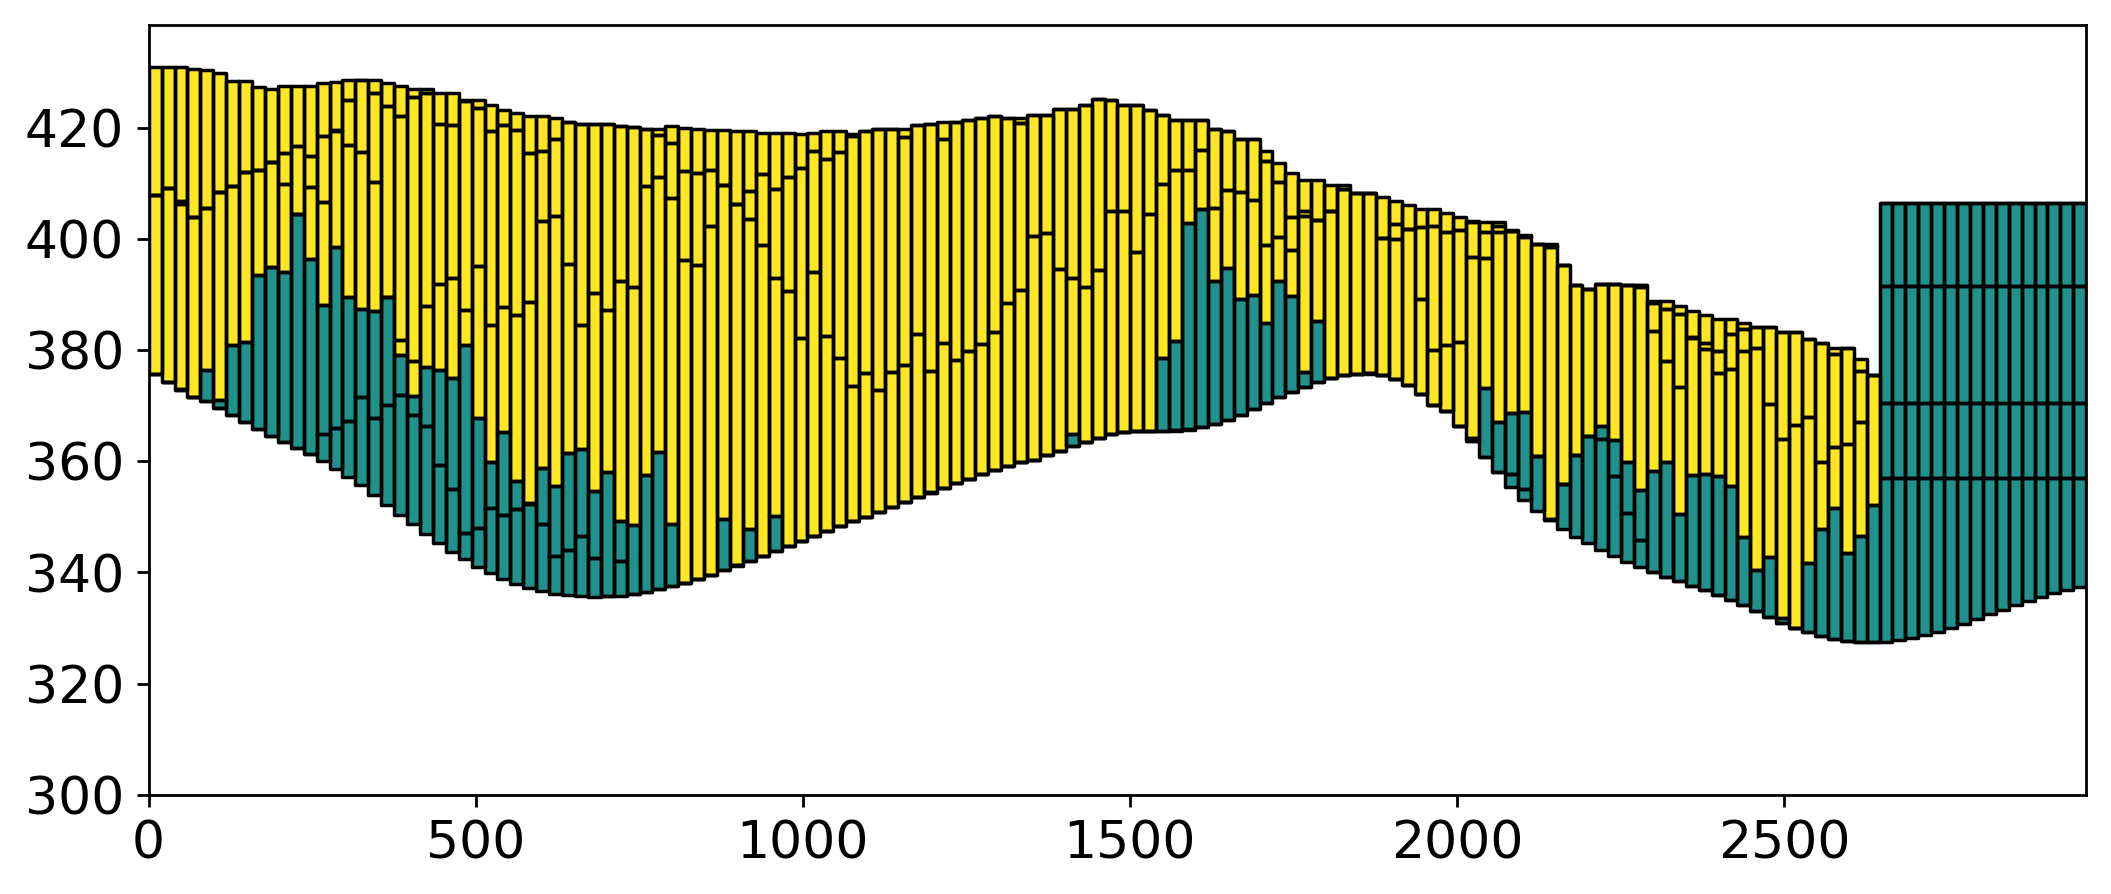

In [15]:
fig = plt.figure(figsize=(10, 4), dpi=250)
ax = fig.add_subplot(1, 1, 1)
modelxsect = fp.plot.PlotCrossSection(model=gwf, line={'Row': 70})
modelxsect.plot_array(idomain)
modelxsect.plot_grid(color="k")

### Hydraulic condictivity

In [16]:
Kx = gwf.npf.k.array
Kz = gwf.npf.k33.array

In [17]:
np.mean(np.log10(Kz), axis=(1, 2))

array([-4.14542678, -5.7750323 , -3.46204092, -5.32209337, -8.        ])

In [20]:
plt.rc('font', size=13) #controls default text size
plt.rc('axes', titlesize=18) #fontsize of the title
plt.rc('axes', labelsize=13) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

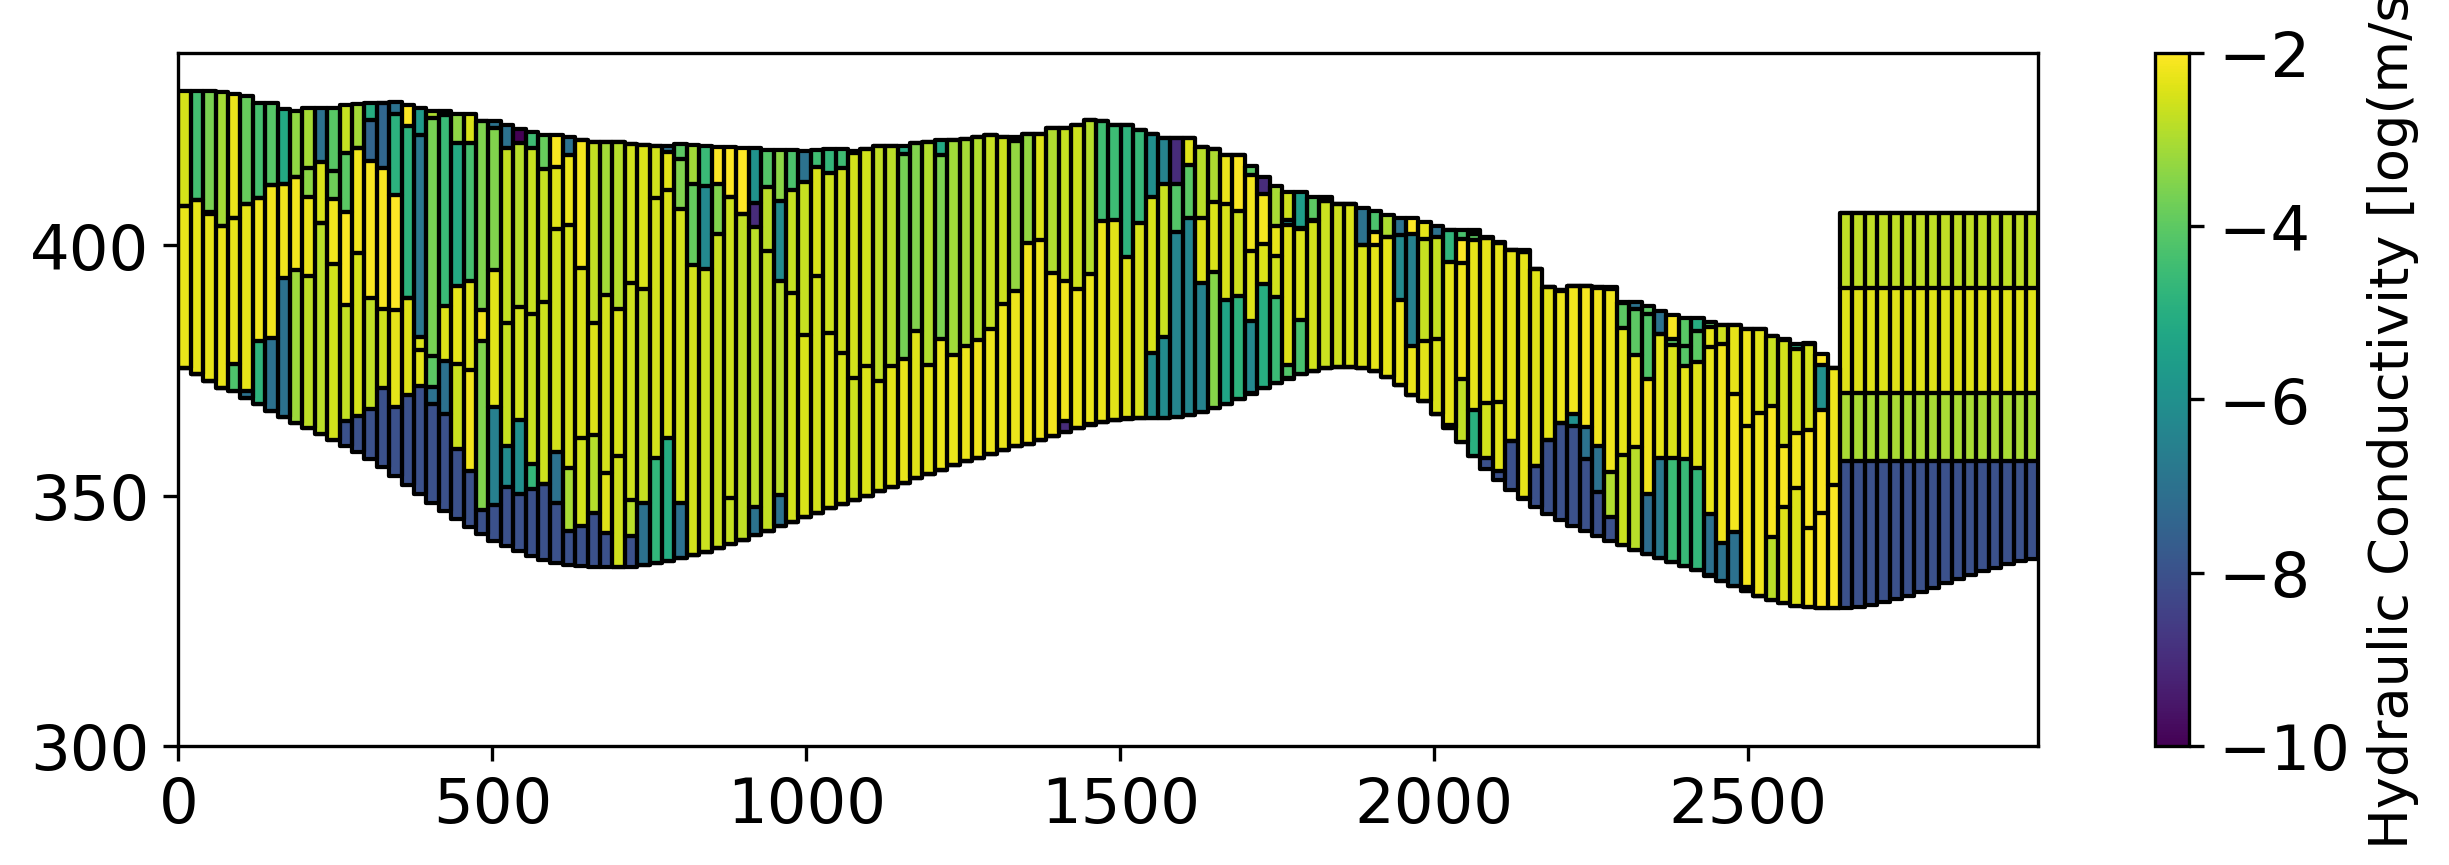

In [21]:
fig = plt.figure(figsize=(10, 3), dpi=300)
ax = fig.add_subplot(1, 1, 1)
modelxsect = fp.plot.PlotCrossSection(model=gwf, line={'Row': 70})
linecollection = modelxsect.plot_grid()

g = modelxsect.plot_array(np.log10(Kx), vmin=-10, vmax=-2)
plt.colorbar(g, label='Hydraulic Conductivity [log(m/s)]')
modelxsect.plot_grid(color="k")

In [22]:
mask = T1.unit_mask("u3", iu=iu)[:, 110]

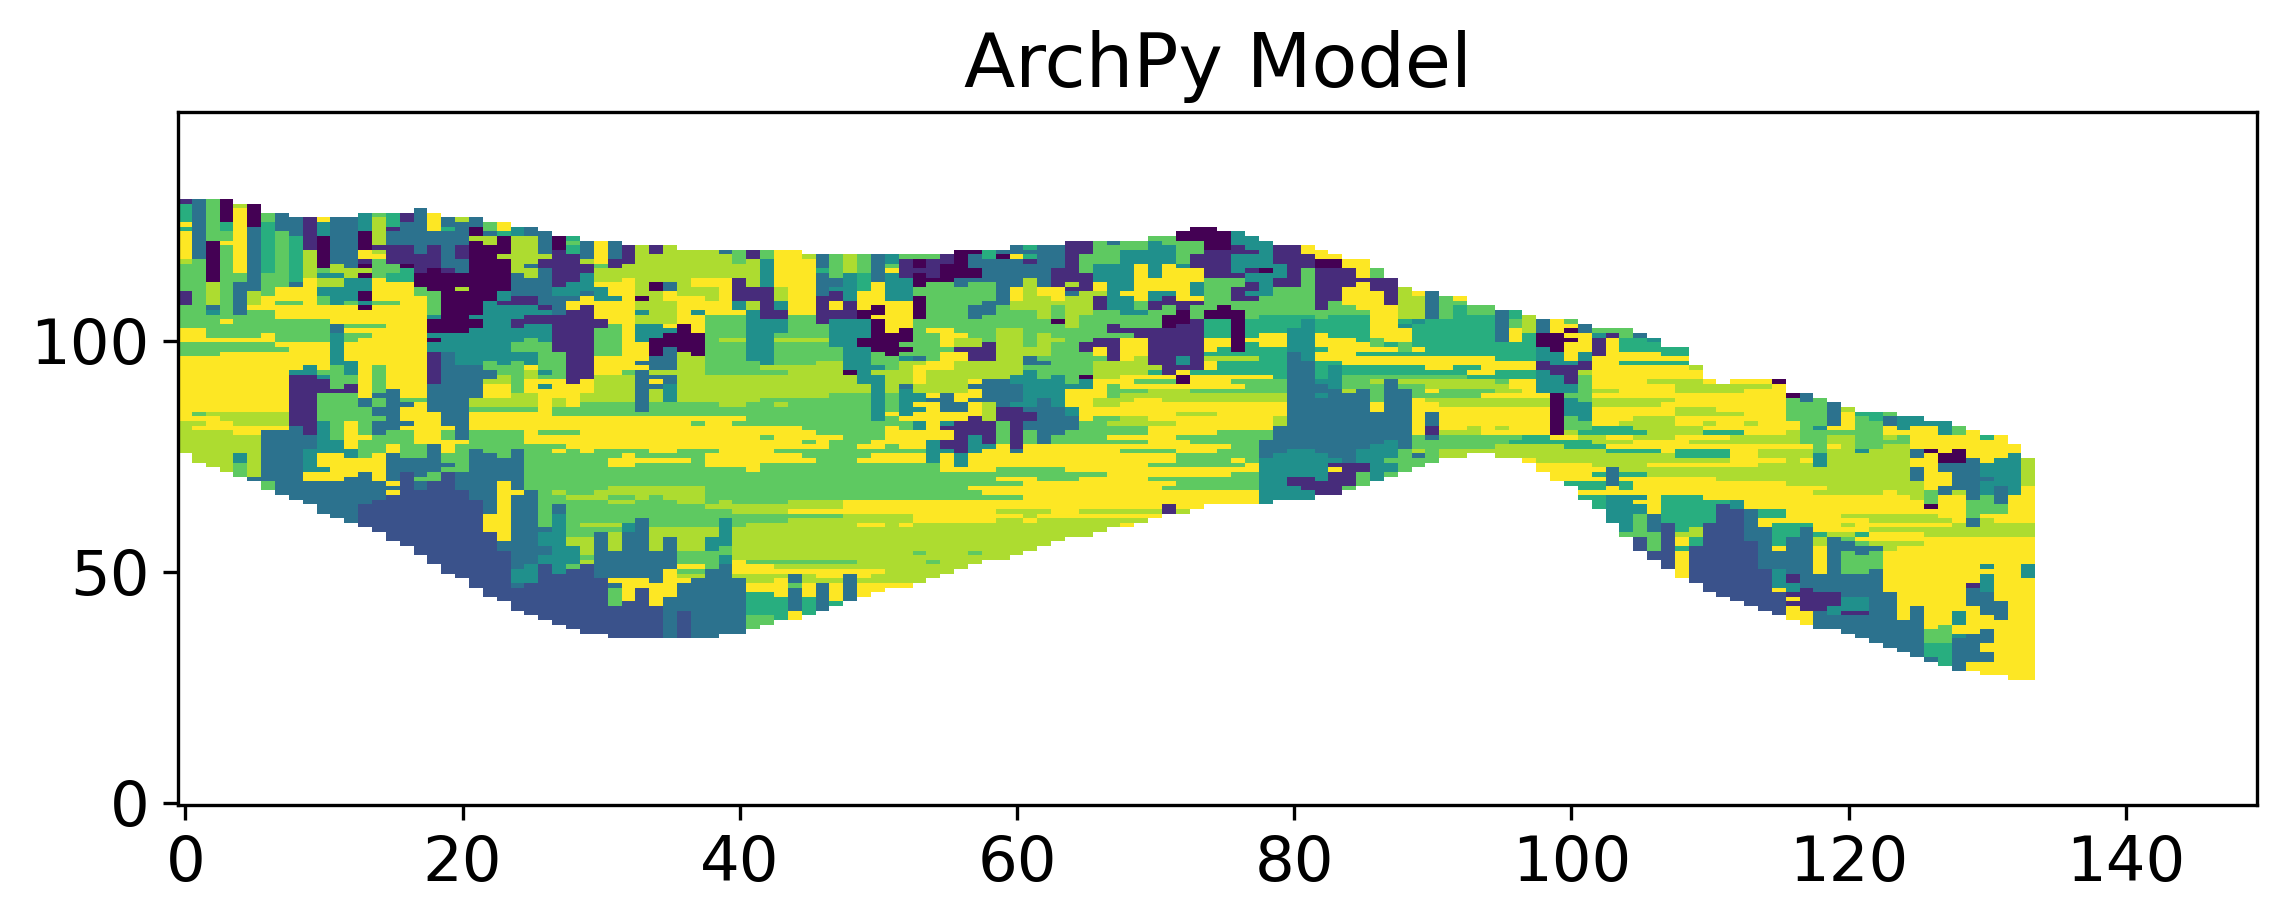

In [24]:
fig = plt.figure(figsize=(10, 3), dpi=300)
arr = T1.get_prop("K")[0, 0, 0, :, 69].copy()

crs = plt.imshow(arr, origin="lower", aspect=1/3)
plt.title("ArchPy Model")
plt.show()

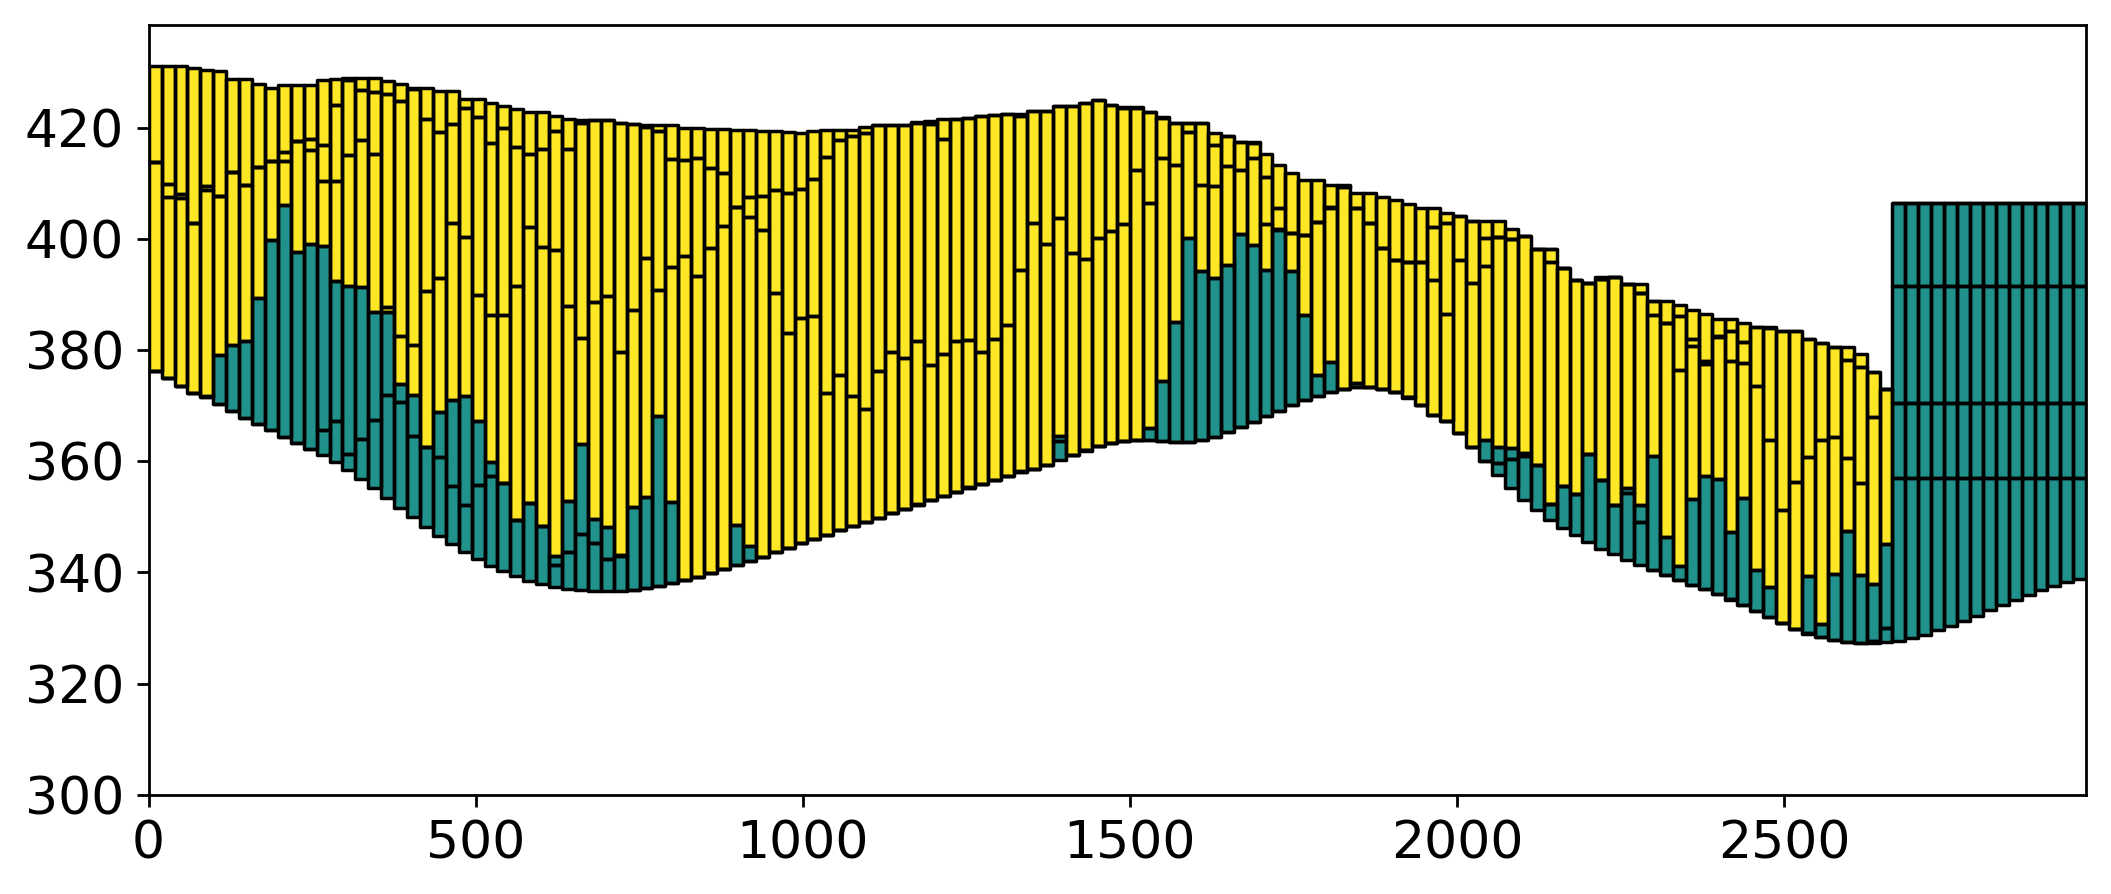

In [25]:
fig = plt.figure(figsize=(10, 4), dpi=250)
ax = fig.add_subplot(1, 1, 1)
modelxsect = fp.plot.PlotCrossSection(model=gwf, line={'Row': 69})
modelxsect.plot_array(idomain)
modelxsect.plot_grid(color="k")

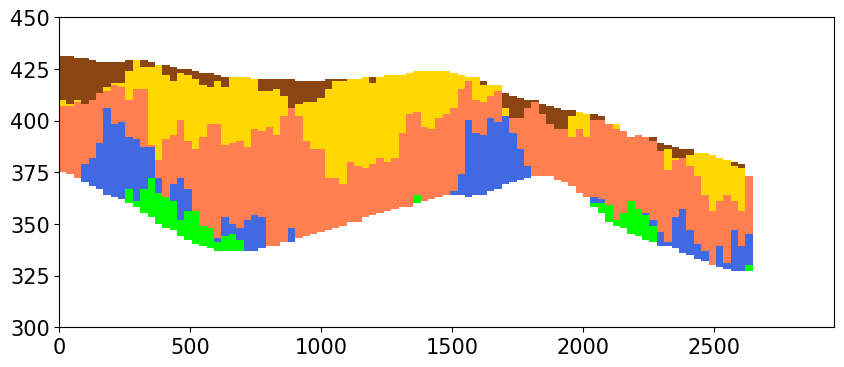

In [26]:
i_cs = 5

T1.plot_cross_section([(X0+1,Y0 + i_cs*(Y1-Y0)/10),(X1-1,Y0 + i_cs*(Y1-Y0)/10)],iu=iu,ratio_aspect=2.5, dist_max=0, width=0,typ='units')

#### Boundary Conditions

In [28]:
riverDf = gpd.read_file(r'data_folder_versoix_sector\Versoix_river.shp')
lakeDf = gpd.read_file(r'data_folder_versoix_sector\BC_lake.shp')
BC_NorthDf = gpd.read_file(r'data_folder_versoix_sector/BC_North.shp') 
BC_WestDf = gpd.read_file(r'data_folder_versoix_sector/BC_West.shp') 
BC_SouthDf = gpd.read_file(r'data_folder_versoix_sector/South_river_2.shp') 

In [29]:
lakeGeom = lakeDf.iloc[0].geometry 

In [30]:
lake_intersected = ix.intersect(lakeGeom)

In [31]:
lake_points = []
for n in lake_intersected.cellids: #Creating a key to id cells
    for m in n:
        lake_points.append(str(n[0])+'-'+str(n[1])) 

In [32]:
mtop = gwf.dis.top.array

In [33]:
mbtom = gwf.dis.botm.array

In [34]:
lake = np.zeros(mtop.shape, dtype=np.int32)
            
lake_list = []

for i in range(lake.shape[0]):
    for q in range(lake.shape[1]):
        if f'{i}-{q}' in lake_points :
            if i < nrow and q < ncol:
                for ilay in range(3):
                    if idomain[ilay, i, q] == 1:
                        lake_list.append([(ilay, i, q), max(mbtom[ilay, i, q]+0.1, 372)])
                        #break

lakDrn = []

for j in lake_list:
    cell = j[0]
    if cell in lst_active_cells:
        lakDrn.append(j)


chdPackage = fp.mf6.ModflowGwfchd(gwf, maxbound=len(lakDrn), stress_period_data=lakDrn, save_flows=True)

In [35]:
riverGeom = riverDf.iloc[0].geometry

In [36]:
river_intersected = ix.intersect(riverGeom)

In [37]:
sgr = fgrid.StructuredGrid(grid.delc*np.ones(nrow), grid.delr*np.ones(ncol),
xoff=X0, yoff=Y0)

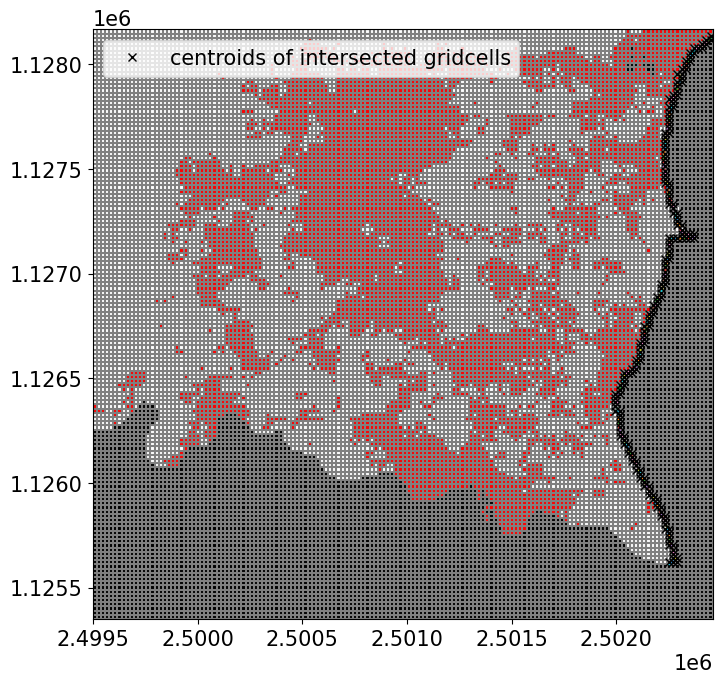

In [38]:
# create a figure and plot the grid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# the intersection object contains some helpful plotting commands
ix.plot_intersection_result(lake_intersected, ax=ax)

# add black x at cell centers
for irow, icol in lake_intersected.cellids:
    (h2,) = ax.plot(
        sgr.xcellcenters[0, icol],
        sgr.ycellcenters[irow, 0],
        "kx",
        label="centroids of intersected gridcells",
    )

# add legend

modelmap = fp.plot.PlotMapView(model=gwf, ax=ax)
actives = modelmap.plot_ibound()
ax.legend([h2], [i.get_label() for i in [h2]], loc="best")
plt.show()

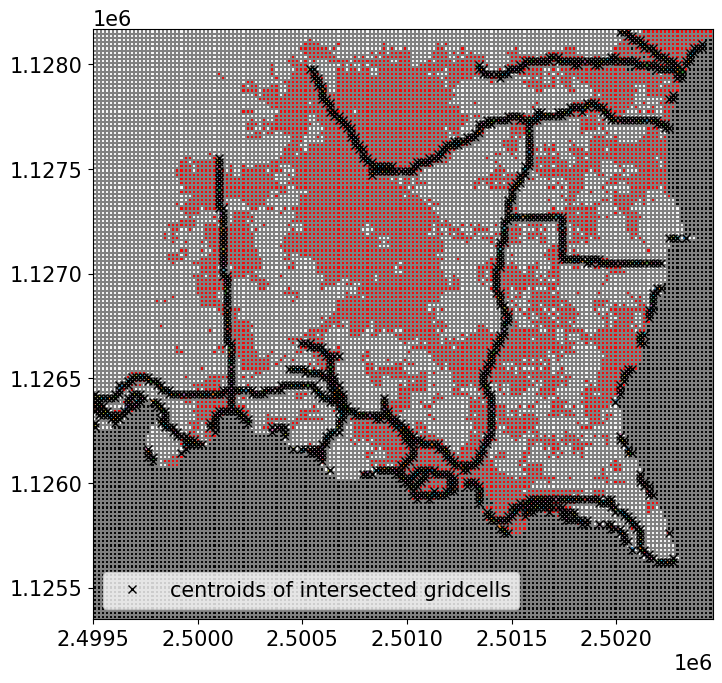

In [39]:
# create a figure and plot the grid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# the intersection object contains some helpful plotting commands
ix.plot_intersection_result(river_intersected, ax=ax)

# add black x at cell centers
for irow, icol in river_intersected.cellids:
    (h2,) = ax.plot(
        sgr.xcellcenters[0, icol],
        sgr.ycellcenters[irow, 0],
        "kx",
        label="centroids of intersected gridcells",
    )

# add legend

modelmap = fp.plot.PlotMapView(model=gwf, ax=ax)
actives = modelmap.plot_ibound()
ax.legend([h2], [i.get_label() for i in [h2]], loc="best")
plt.show()

In [40]:
riv_points = []
for n in river_intersected.cellids: #Creating a key to id cells
    for m in n:
        riv_points.append(str(n[0])+'-'+str(n[1])) 

In [41]:
#Add the drain package (DRN) to the MODFLOW model
river = np.zeros(mtop.shape, dtype=np.int32)
riv_list = []
for i in range(river.shape[0]):
    for q in range(river.shape[1]):
        if f'{i}-{q}' in riv_points :
            riv_list.append([0, i, q, mtop[i,q]-1, 0.0008, mtop[i,q]-2]) 

riv_inter = []
riv_inter_u7 = []
riv_inter_u9 = []

for j in riv_list:
    cell = (j[0],j[1],j[2])
    cell_u7 = (1,j[1],j[2])
    cell_u9 = (2,j[1],j[2])
    if cell in lst_active_cells:
        riv_inter.append(((cell), j[3], j[4], j[5]))
    elif cell_u7 in lst_active_cells:
        riv_inter.append(((cell_u7), j[3], j[4], j[5]))
    elif cell_u9 in lst_active_cells:
        riv_inter.append(((cell_u9), j[3], j[4], j[5]))

rivDrn = {0:riv_inter}

riv = fp.mf6.ModflowGwfriv(gwf, maxbound=(len(rivDrn)), stress_period_data=rivDrn,save_flows=True)


In [42]:
NorthGeom = BC_NorthDf.iloc[0].geometry
North_intersected = ix.intersect(NorthGeom)
WestGeom = BC_WestDf.iloc[0].geometry
West_intersected = ix.intersect(WestGeom)
SouthGeom = BC_SouthDf.iloc[0].geometry
South_intersected = ix.intersect(SouthGeom)

In [43]:
North_points = []
for n in North_intersected.cellids: #Creating a key to id cells
    for m in n:
        North_points.append(str(n[0])+'-'+str(n[1])) 

West_points = []
for n in West_intersected.cellids: #Creating a key to id cells
    for m in n:
        West_points.append(str(n[0])+'-'+str(n[1])) 

South_points = []
for n in South_intersected.cellids: #Creating a key to id cells
    for m in n:
        South_points.append(str(n[0])+'-'+str(n[1])) 

In [44]:
# North
North = np.zeros(mtop.shape, dtype=np.int32)

North_list = []
for i in range(North.shape[0]):
    for q in range(North.shape[1]):
        if f'{i}-{q}' in North_points :
            if i < nrow and q < ncol:
                cell = (2, i, q)
                if cell in lst_active_cells:
                    North_list.append(cell)
            else:
                print(f"Out of bound : ({i}, {q})")

total_flux = 0.70
NorthDrn = []
for cell in North_list:
    NorthDrn.append((cell, total_flux/len(North_list)))

# West
West = np.zeros(mtop.shape, dtype=np.int32)

West_list = []
for i in range(West.shape[0]):
    for q in range(West.shape[1]):
        if f'{i}-{q}' in West_points :
            if i < nrow and q < ncol:
                cell = (2, i, q)
                if cell in lst_active_cells:
                    West_list.append(cell)
                cell = (1, i, q)
                if cell in lst_active_cells:
                    West_list.append(cell)
            else:
                print(f"Out of bound : ({i}, {q})")

total_flux = 0.60
WestDrn = []
for cell in West_list:
    WestDrn.append((cell, total_flux/len(West_list)))

# South
South = np.zeros(mtop.shape, dtype=np.int32)

South_list = []
for i in range(South.shape[0]):
    for q in range(South.shape[1]):
        if f'{i}-{q}' in South_points :
            if i < nrow and q < ncol:
                cell = (2, i, q)
                if cell in lst_active_cells:
                    South_list.append(cell)
            else:
                print(f"Out of bound : ({i}, {q})")

total_flux = 0.20
SouthDrn = []
for cell in South_list:
    SouthDrn.append((cell, total_flux/len(South_list)))

welPackagen = fp.mf6.ModflowGwfwel(gwf, maxbound=len(NorthDrn),stress_period_data=NorthDrn, save_flows=True)
welPackagew = fp.mf6.ModflowGwfwel(gwf, maxbound=len(WestDrn),stress_period_data=WestDrn, save_flows=True)
welPackages = fp.mf6.ModflowGwfwel(gwf, maxbound=len(SouthDrn),stress_period_data=SouthDrn, save_flows=True)

In [45]:
u3_k = gwf.npf.k.array[0]
u3_k[u3_k == 0.0019869099371829296] = np.nan

u7_k = gwf.npf.k.array[1]
u7_k[u7_k == 0.0017586733566143796] = np.nan

u9_k = gwf.npf.k.array[2]
u9_k[u9_k == 0.003957629756952273] = np.nan

In [46]:
plt.rc('font', size=12) #controls default text size
plt.rc('axes', titlesize=18) #fontsize of the title
plt.rc('axes', labelsize=10) #fontsize of the x and y labels
plt.rc('xtick', labelsize=12) #fontsize of the x tick labels
plt.rc('ytick', labelsize=12) #fontsize of the y tick labels
plt.rc('legend', fontsize=10) #fontsize of the legend

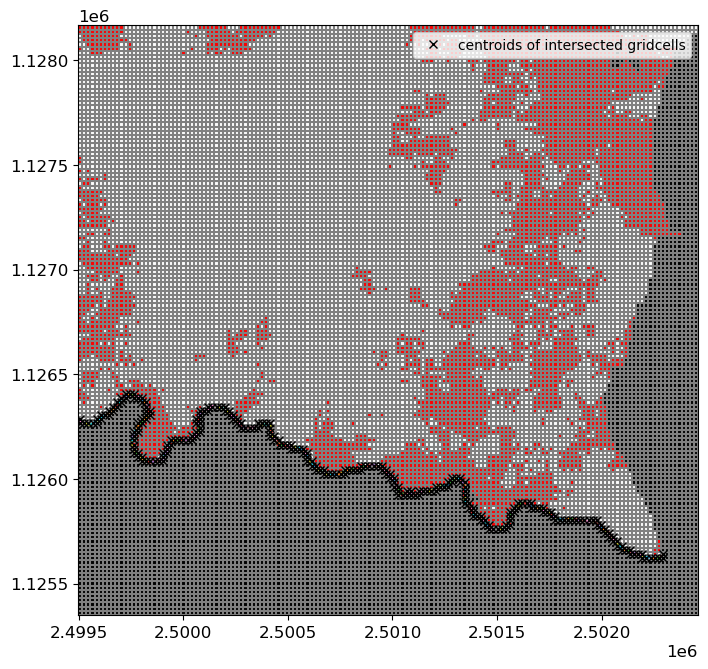

In [47]:
# create a figure and plot the grid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# the intersection object contains some helpful plotting commands
ix.plot_intersection_result(South_intersected, ax=ax)

# add black x at cell centers
for irow, icol in South_intersected.cellids:
    (h2,) = ax.plot(
        sgr.xcellcenters[0, icol],
        sgr.ycellcenters[irow, 0],
        "kx",
        label="centroids of intersected gridcells",
    )

# add legend

modelmap = fp.plot.PlotMapView(model=gwf, ax=ax, layer=1)
actives = modelmap.plot_ibound()
ax.legend([h2], [i.get_label() for i in [h2]], loc="best")
plt.show()

### Simulation

In [50]:
sim.ims.remove()
inner_dvclose = 1e-3
ims = fp.mf6.ModflowIms(sim, complexity="complex", inner_dvclose=inner_dvclose)

archpy_flow.set_strt(np.repeat(mtop, 5,axis=0).reshape(5, nrow, ncol,order='F'))

In [51]:
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model test...
    writing model name file...
    writing package dis...
    writing package oc...
    writing package npf...
    writing package chd_0...
    writing package riv_0...
INFORMATION: maxbound in ('gwf6', 'riv', 'dimensions') changed to 947 based on size of stress_period_data
    writing package wel_0...
    writing package wel_1...
    writing package wel_2...
    writing package ic...


In [52]:
sim.run_simulation()

FloPy is using the following executable to run the model: ..\Exe_mf6\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 14 2025 13:40:10 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shal

(True, [])

In [53]:
print(gwf.modelgrid.delr)
print(gwf.modelgrid.delc)

[19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667 19.74666667
 19.74666667 19.74666667 19.74666667 19.74666667 19

In [54]:
print(gwf.dis.top.array.min(), gwf.dis.botm.array.min())

372.0 300.0


In [55]:
print(gwf.npf.k.array.min())  # or np.min(model.npf.k.array)


9.999999439624929e-11


In [56]:
print(gwf.ic.strt.array.min())  # Should not be NaN or extreme


372.0


### Results

In [57]:
import flopy
from flopy.plot import PlotMapView

In [58]:
heads = archpy_flow.get_heads(kstpkper=(0, 0))
heads[heads == 1e30] = np.nan

[]

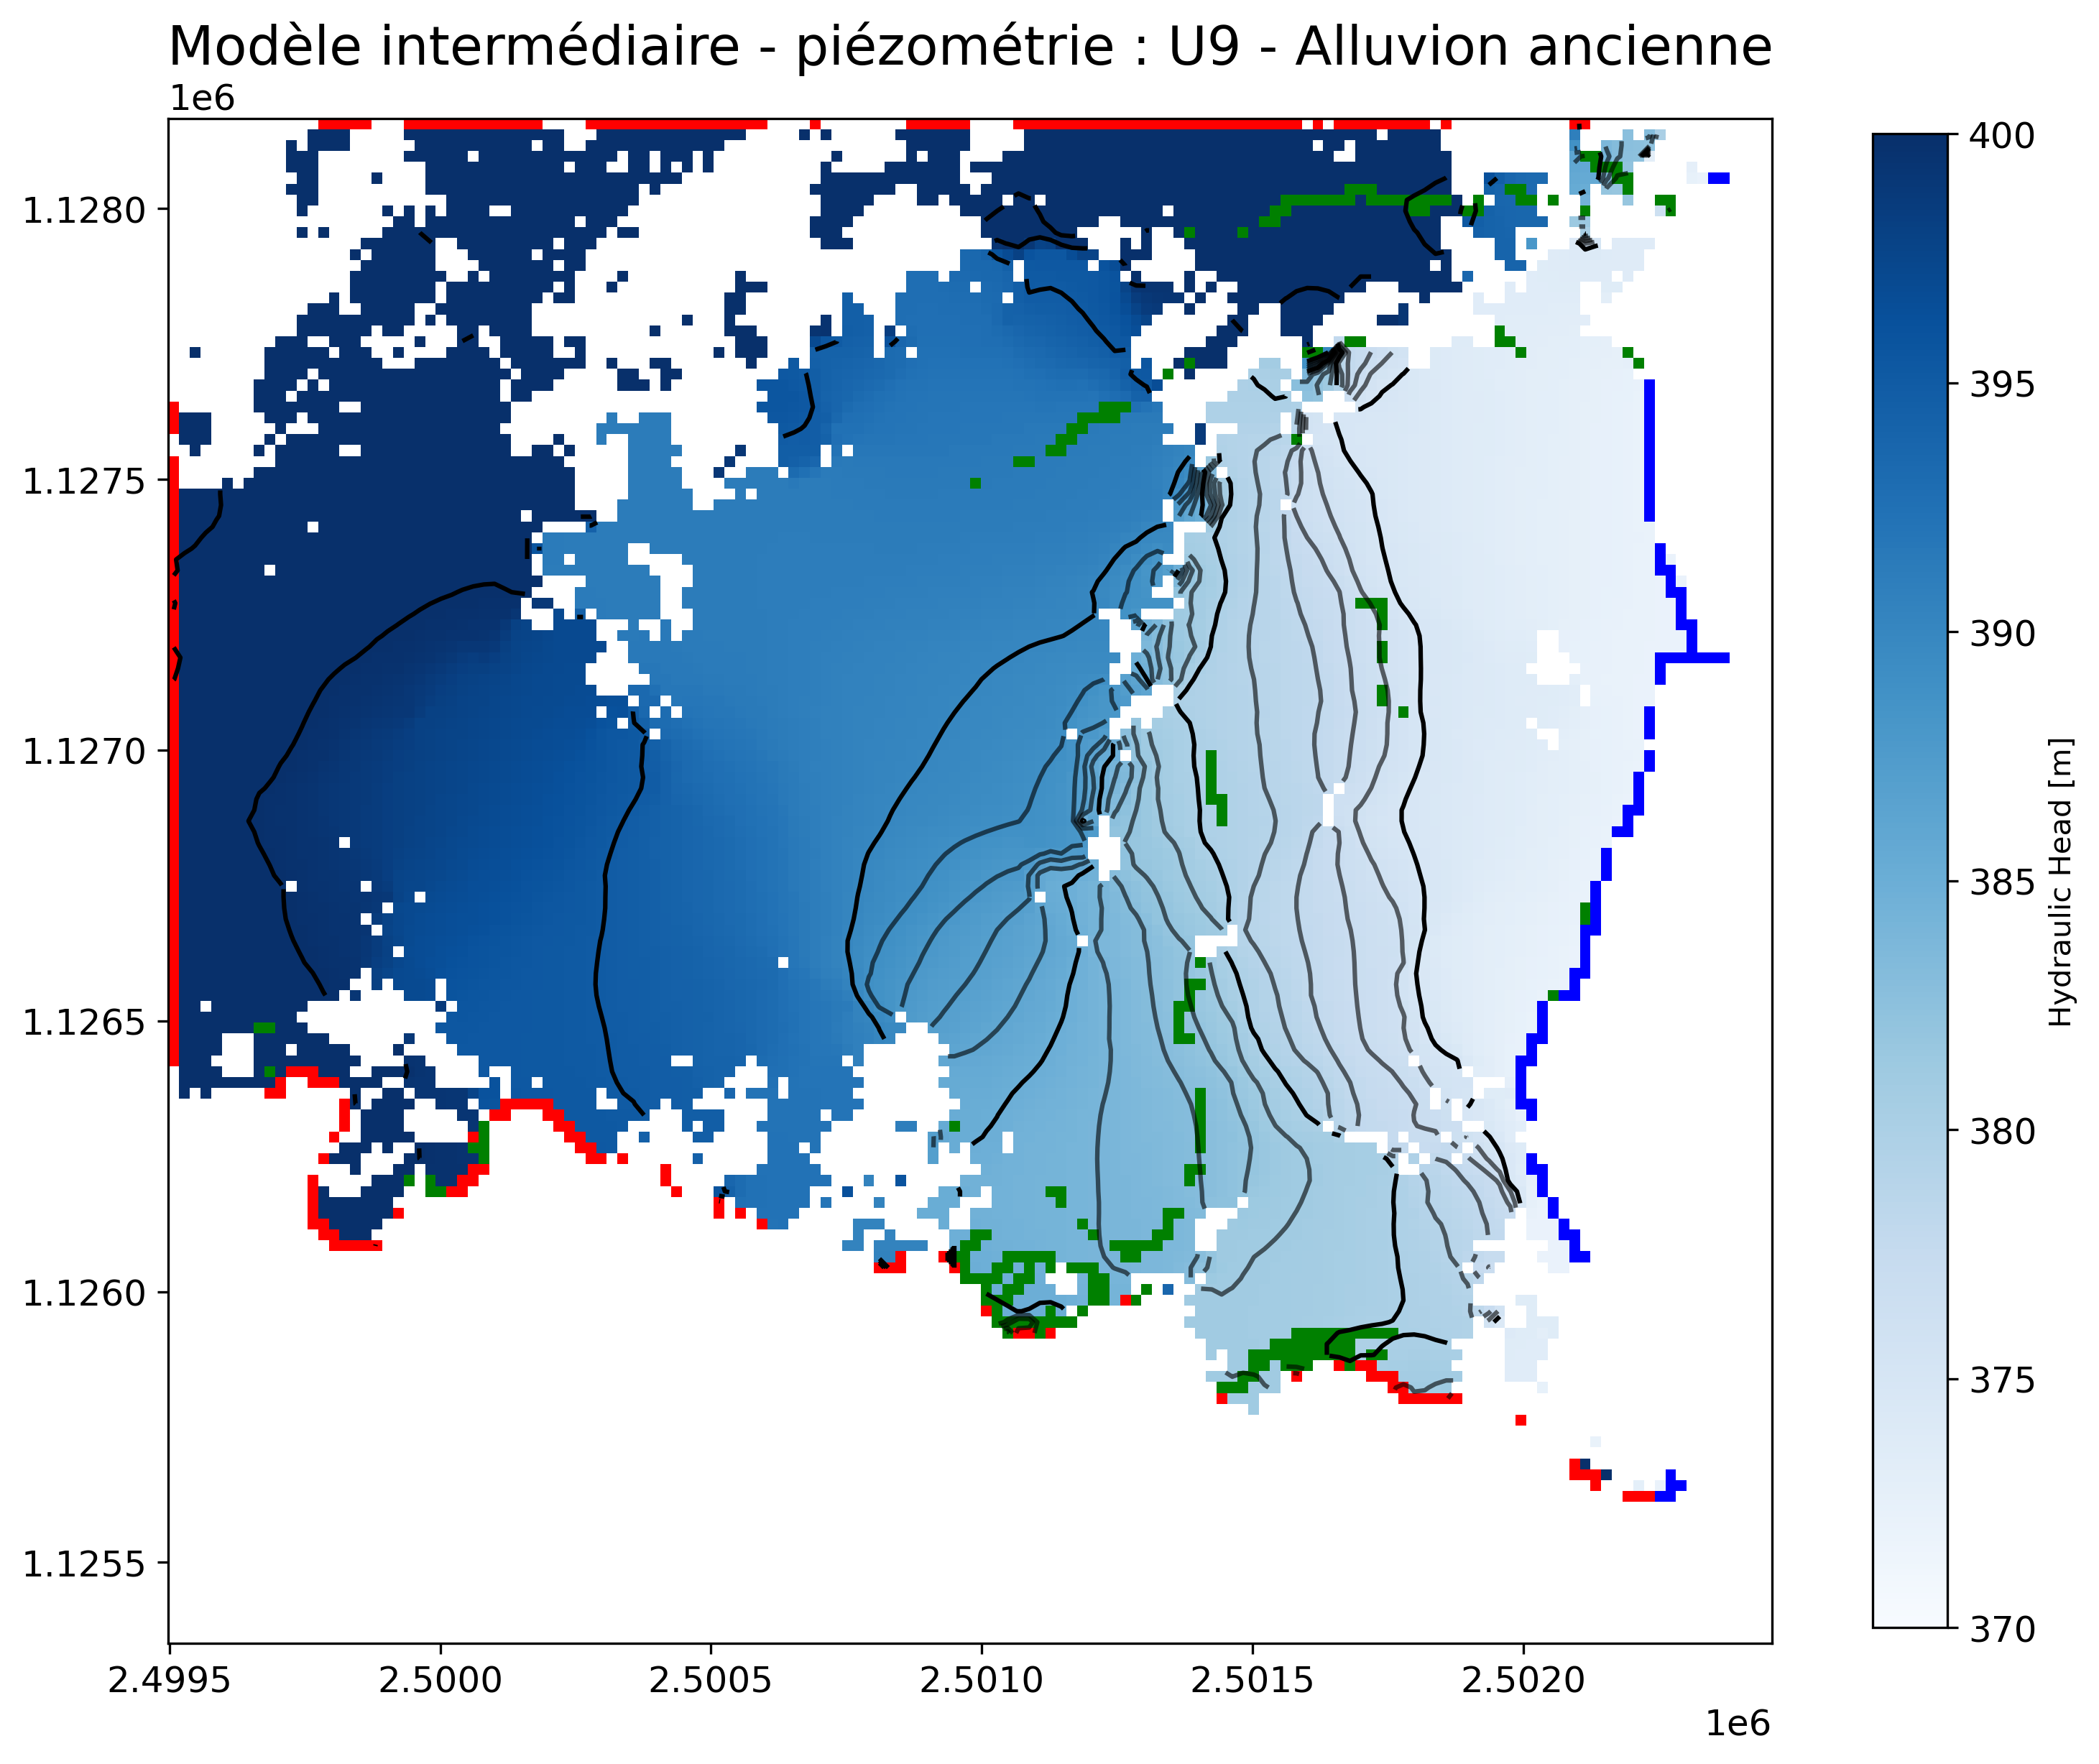

In [59]:
fig = plt.figure(figsize=(12, 12), dpi=300)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Modèle intermédiaire - piézométrie : U9 - Alluvion ancienne")
#ax.set_title("Modèle intermédiaire - piézométrie : U7 - Formation würmienne")
#ax.set_title("Modèle intermédiaire - piézométrie : U3 - Dépôts récents")
mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(heads, cmap="Blues", vmax=400, vmin=370)

# contouring the head array
contour_set_10 = mapview.contour_array(heads, colors="k", levels=[376, 377, 378, 379, 381, 382, 383, 384, 386, 387, 388, 389], alpha=0.6)
contour_set = mapview.contour_array(heads, colors="k", levels=[370, 375, 380, 385, 390, 395, 400, 405])
#plt.clabel(contour_set, fmt="%.1f", colors="k", fontsize=11)
#plt.clabel(contour_set_10, fmt="%.1f", colors="k", fontsize=8)
linecollection = mapview.plot_grid(lw=0.25, color="k", alpha=0)

mapview.plot_bc("wel", color="red")
mapview.plot_bc("riv", color="green")
mapview.plot_bc("chd", color="blue")

cb = plt.colorbar(pc, shrink=0.75, ax=ax, label='Hydraulic Head [m]')
plt.plot()

In [60]:
#Observation heads
obs_data = np.loadtxt("data_folder_versoix_sector/obs_heads.csv", delimiter=';',skiprows=1)

In [61]:
x_obs = obs_data[:,0]
y_obs = obs_data[:,1]
h_obs = obs_data[:,2]

In [62]:
plt.rc('font', size=15) #controls default text size
plt.rc('axes', titlesize=20) #fontsize of the title
plt.rc('axes', labelsize=15) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

[]

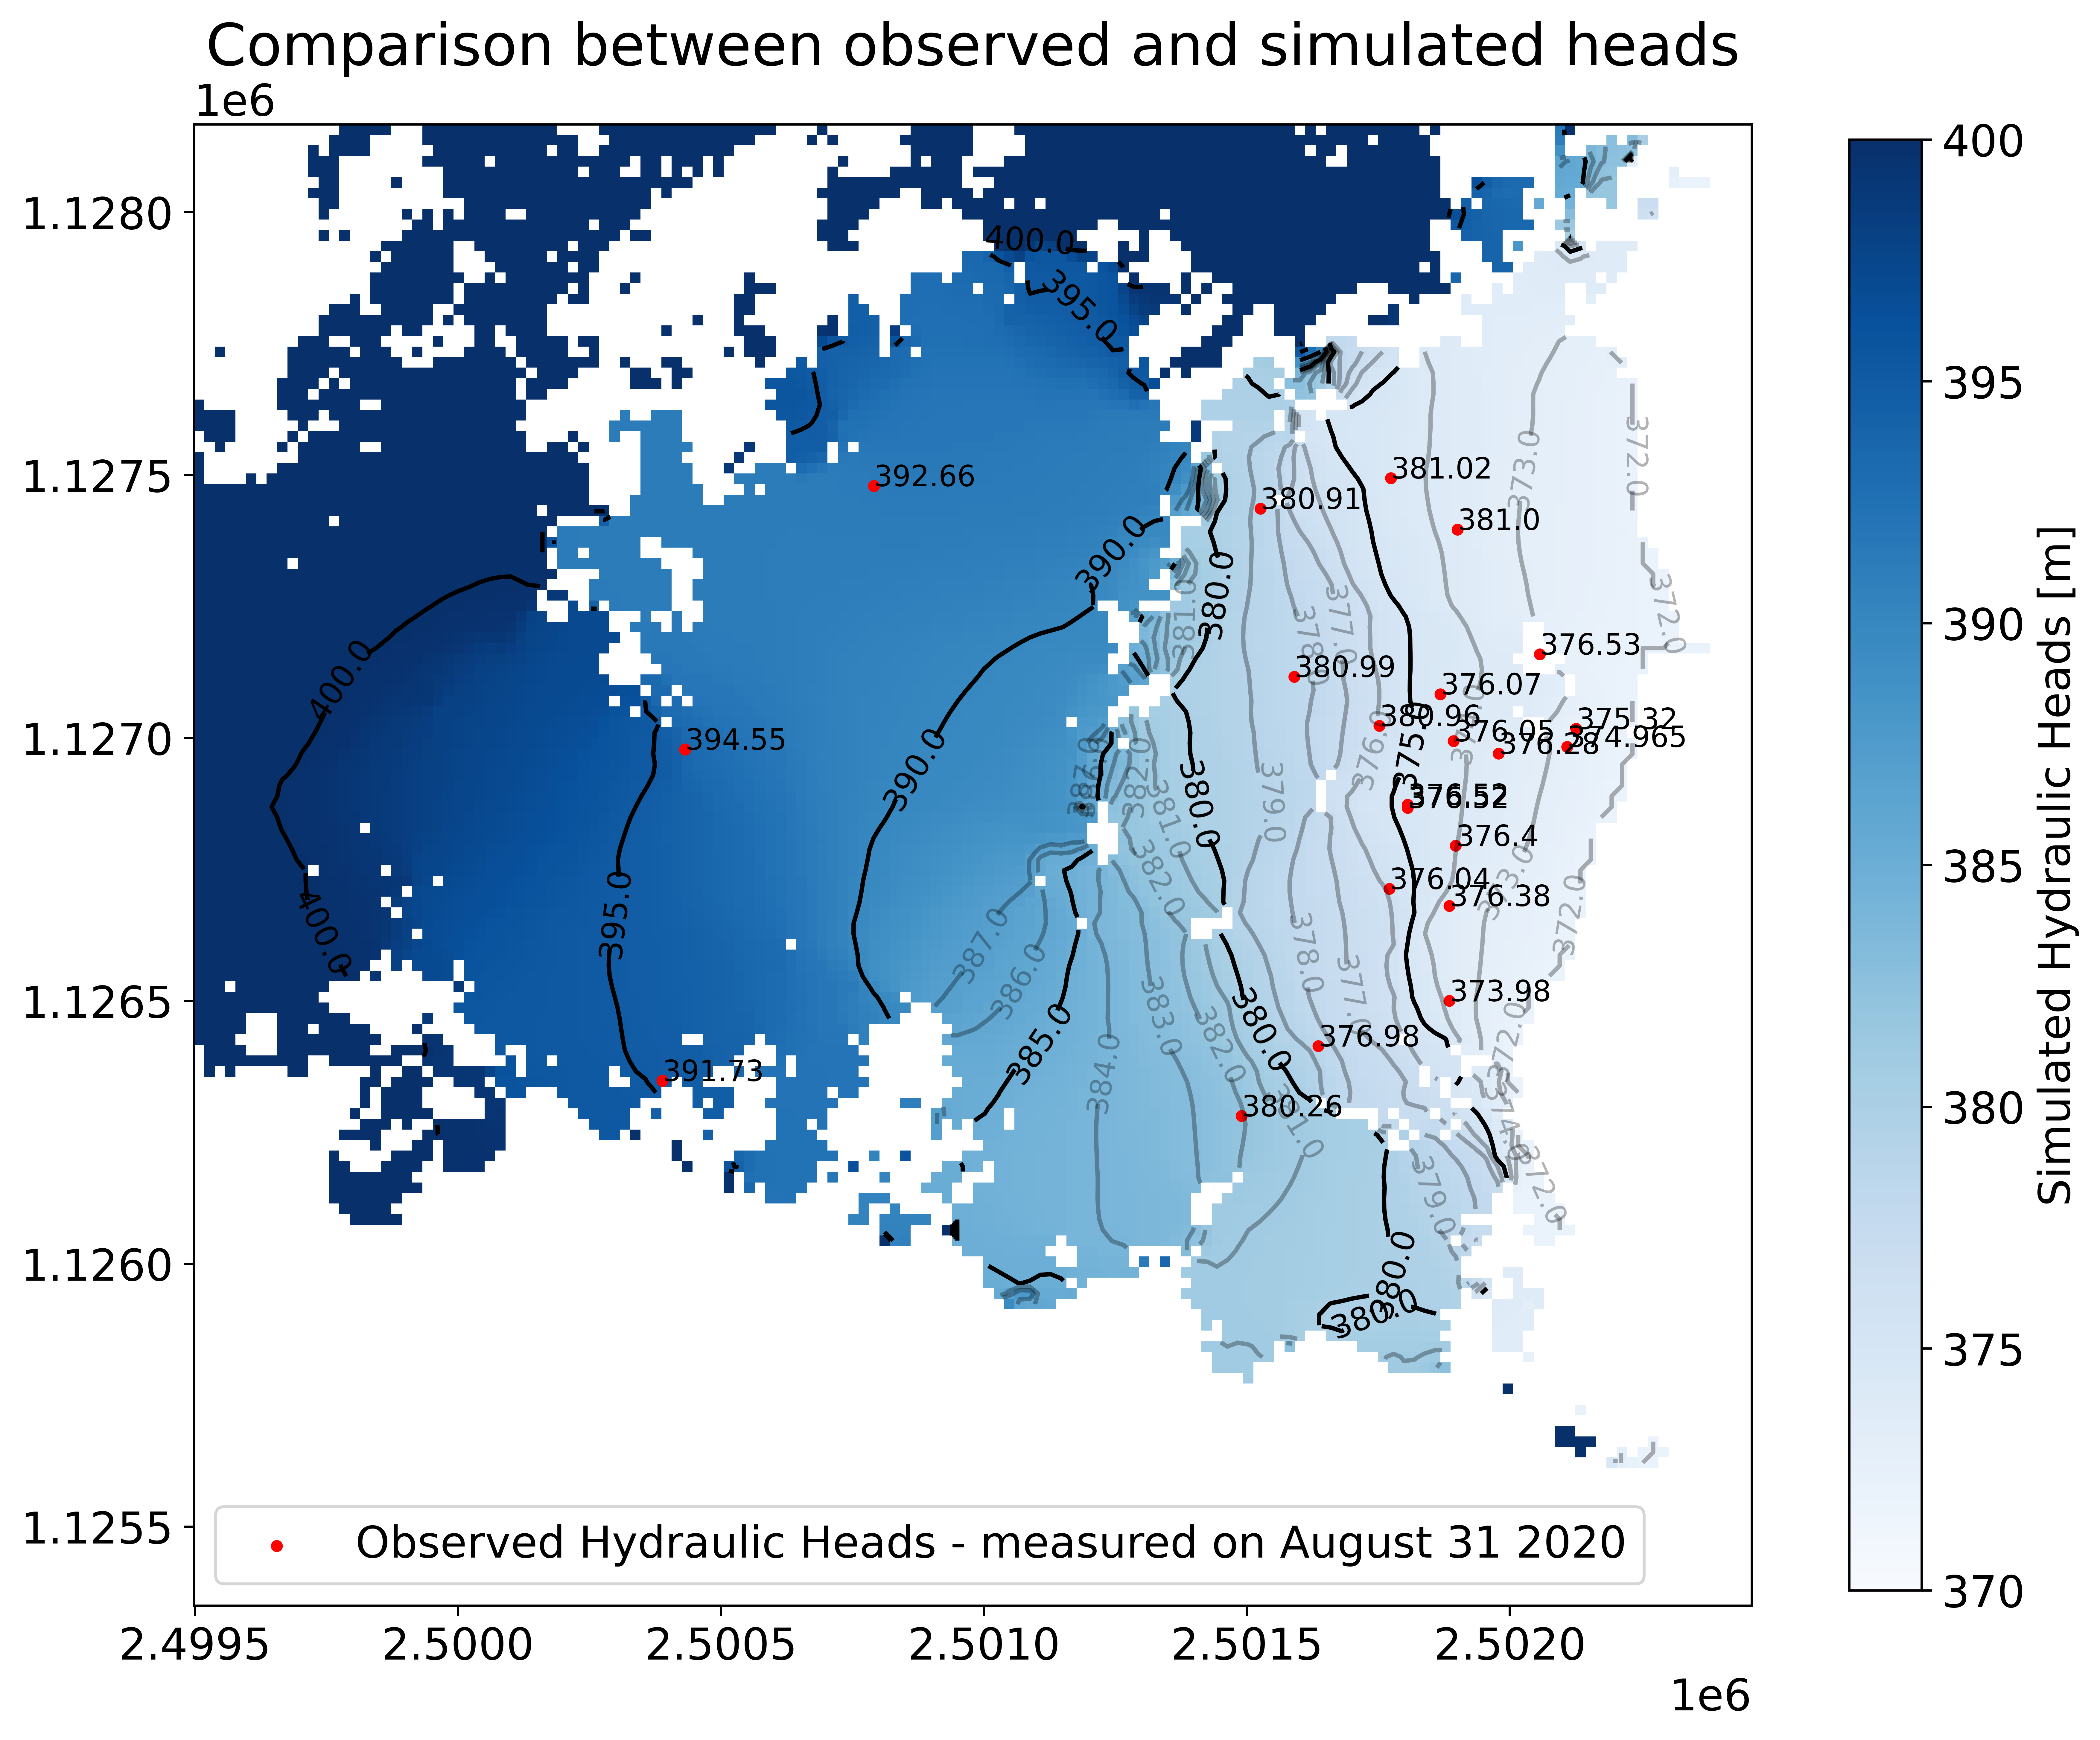

In [63]:
fig = plt.figure(figsize=(12, 12), dpi=700)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Modèle intermédiaire - piézométrie : Alluvion ancienne")

mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(heads, cmap="Blues", vmax=400, vmin=370)

# contouring the head array
contour_set_10 = mapview.contour_array(heads, colors="k", levels=[372, 373, 374, 376, 377, 378, 379, 381, 382, 383, 384, 386,387], alpha=0.3)
contour_set = mapview.contour_array(heads, colors="k", levels=[370, 375, 380, 385, 390, 395,400])
plt.clabel(contour_set, fmt="%.1f", colors="k", fontsize=11)
plt.clabel(contour_set_10, fmt="%.1f", colors="k", fontsize=10)
linecollection = mapview.plot_grid(lw=0.25, color="k", alpha=0)

#mapview.plot_bc("wel", color="red")
#mapview.plot_bc("riv", color="green")
plt.scatter(x=x_obs, y=y_obs, s=h_obs/10, c='red', marker='.', label='Observed Hydraulic Heads - measured on August 31 2020')
for i in range(len(x_obs)):
    plt.text(x_obs[i], y_obs[i], str(h_obs[i]), size=10)
plt.title('Comparison between observed and simulated heads')

cb = plt.colorbar(pc, shrink=0.75, ax=ax, label='Simulated Hydraulic Heads [m]')
plt.legend(loc='lower left')
plt.plot()

In [64]:
#Observation heads
obs_data = np.loadtxt("data_folder_versoix_sector/obs_heads.csv", delimiter=';',skiprows=1)

In [65]:
x_obs = obs_data[:,0]
y_obs = obs_data[:,1]
h_obs = obs_data[:,2]

In [66]:
x_data = np.zeros((150, 140))
y_data = np.zeros((150, 140))

x_lenght = X1 - X0
y_lenght = Y1 - Y0

x_space = np.linspace(X0, X1, num=150)
y_space = np.linspace(Y0, Y1, num=140)

for ix in range(len(x_space)):    
    for iy in range(len(y_space)):
        x_data[ix, iy] = x_space[ix]
        y_data[ix, iy] = y_space[iy]

In [67]:
heads.shape

(5, 140, 150)

In [68]:
h_sims = []
h_sim = []

for i_obs in range(len(h_obs)):
    x_obs_pt = x_obs[i_obs]
    y_obs_pt = y_obs[i_obs]
    h_obs_pt = h_obs[i_obs]
    
    
    AA_head = heads[2]
    

    for xi in range(150-1):
        for yi in range(140-1):
            if x_data[xi, yi] <= x_obs_pt and y_data[xi, yi] <= y_obs_pt and x_data[xi+1, yi] > x_obs_pt and y_data[xi, yi+1] > y_obs_pt:
                if AA_head[yi, xi] == AA_head[yi, xi] :#check that is not nan 
                    h_sim.append(AA_head[yi, xi])
                else:
                    h_sim.append(np.nan)
                break
h_sims.append(h_sim)

In [71]:
plt.rc('font', size=10) #controls default text size
plt.rc('axes', titlesize=15) #fontsize of the title
plt.rc('axes', labelsize=10) #fontsize of the x and y labels
plt.rc('xtick', labelsize=10) #fontsize of the x tick labels
plt.rc('ytick', labelsize=10) #fontsize of the y tick labels
plt.rc('legend', fontsize=10) #fontsize of the legend

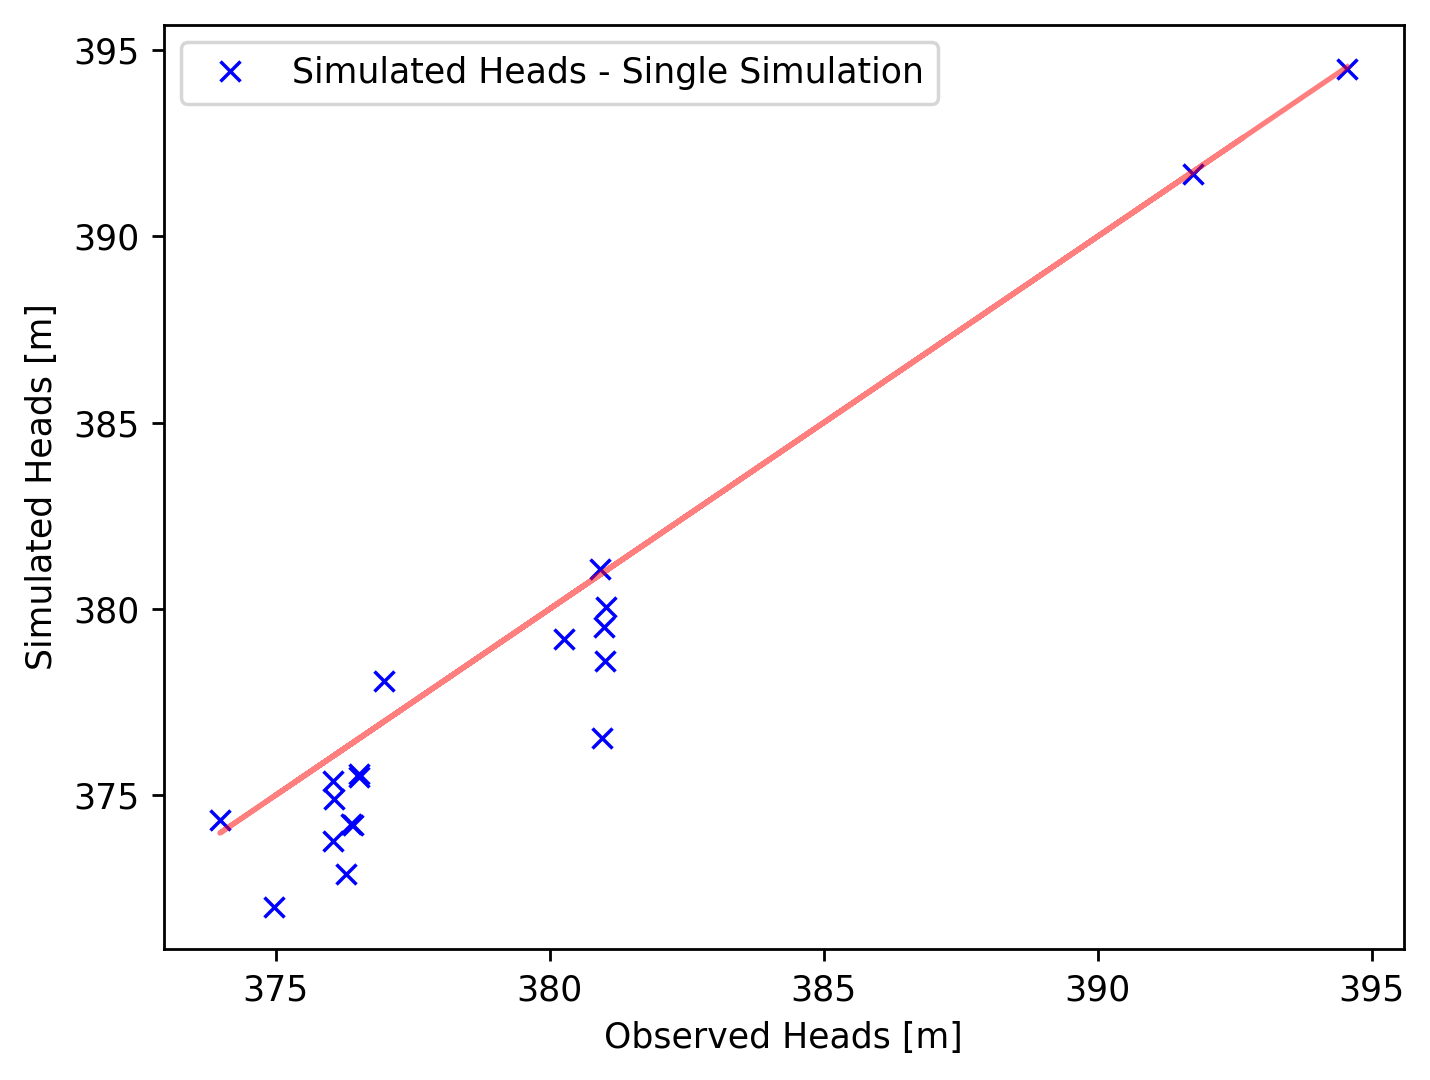

In [73]:
fig = plt.figure(dpi=250)
plt.plot(h_obs,h_sims[0], 'x',color='b', label='Simulated Heads - Single Simulation')
plt.plot(h_obs,h_obs, '-', color='r', alpha=0.5)
#plt.plot(h_obs,h_obs, '.', color='r', alpha=0.5)
#plt.title('Comparison between observed and simulated heads')
plt.xlabel('Observed Heads [m]')
plt.ylabel('Simulated Heads [m]')
plt.legend()
plt.show()

In [75]:
plt.rc('font', size=15) #controls default text size
plt.rc('axes', titlesize=20) #fontsize of the title
plt.rc('axes', labelsize=15) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

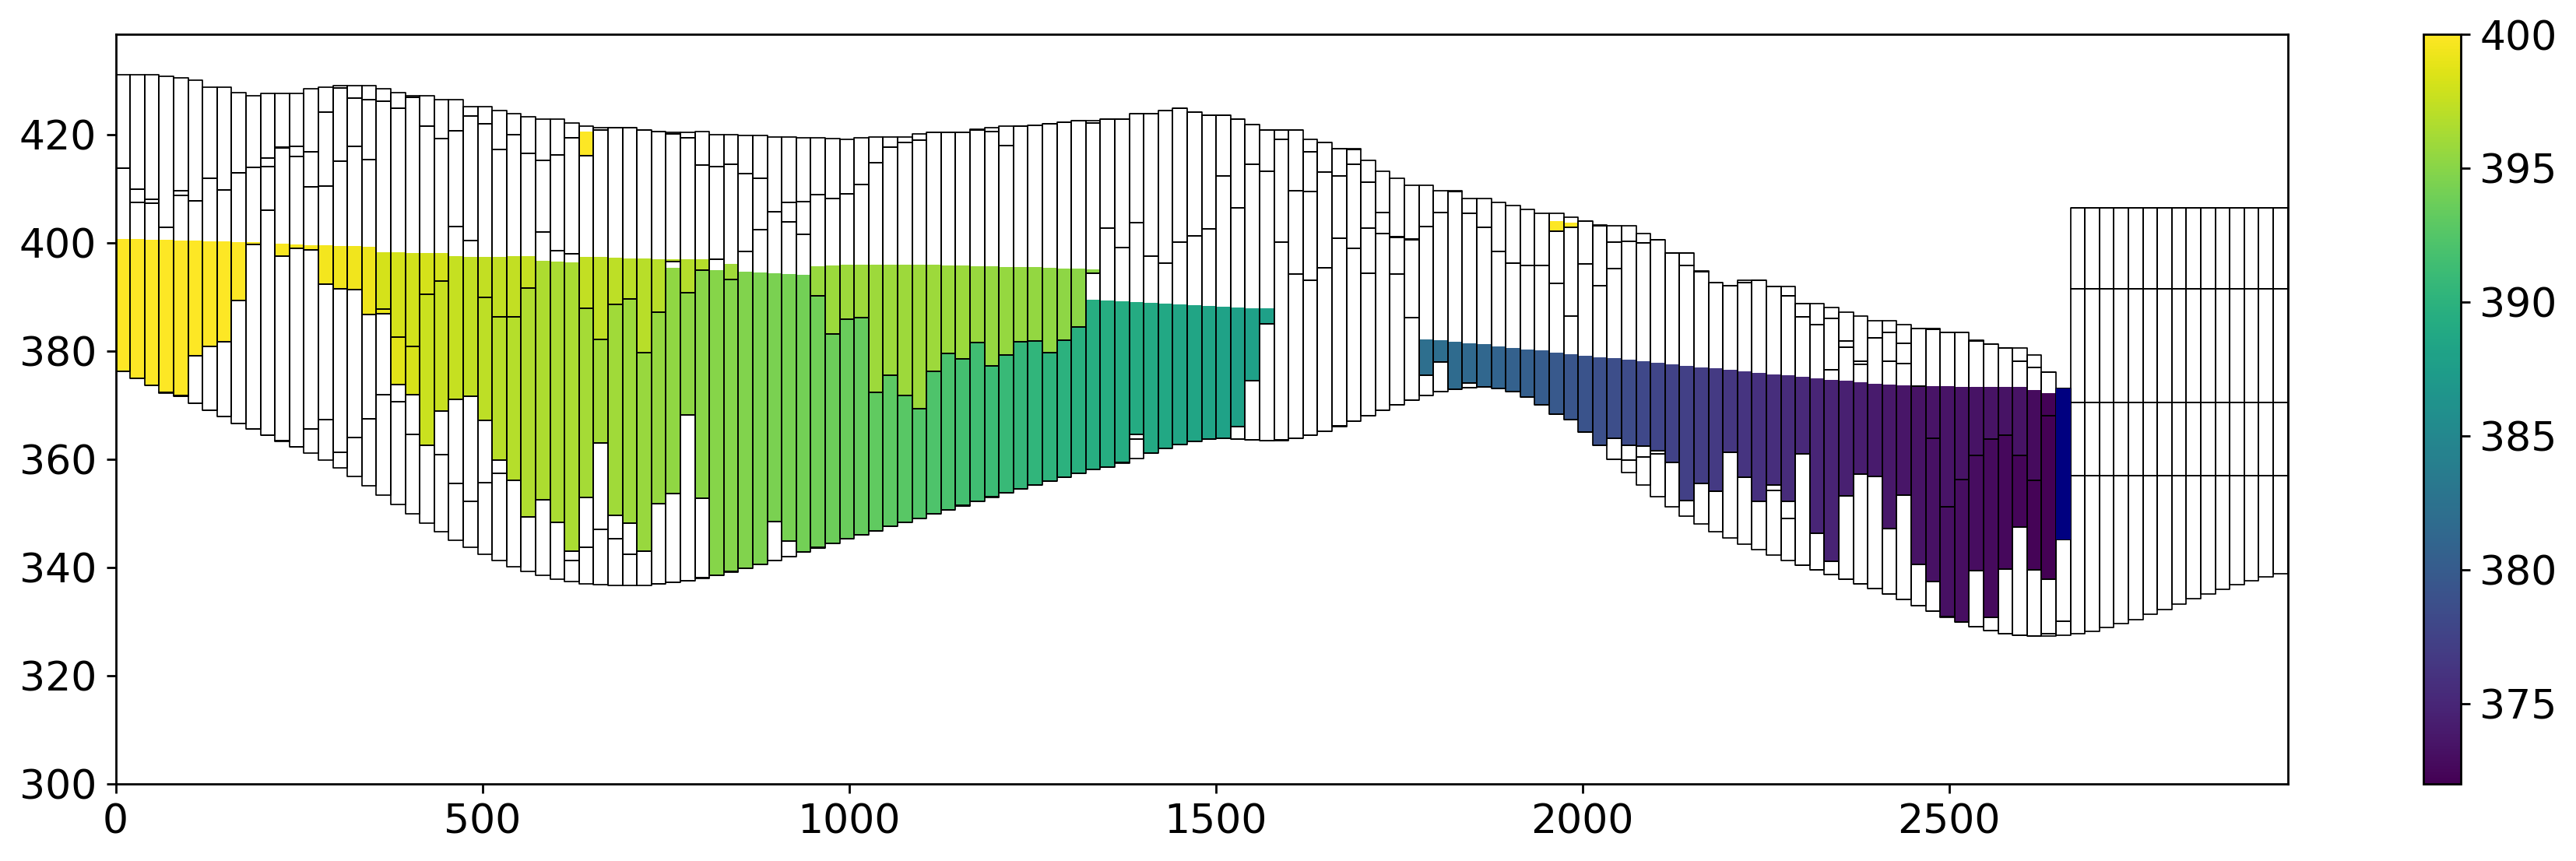

In [78]:
fig = plt.figure(figsize=(18, 5), dpi=250)

ax = fig.add_subplot(1, 1, 1)
xsect = fp.plot.PlotCrossSection(model=gwf, line={'Row':69})
pc = xsect.plot_array(heads, head=heads, alpha=1, vmax=400)
patches = xsect.plot_ibound(head=heads)

xsect.plot_grid(linewidth=0.5, color="black")
xsect.plot_bc("CHD")
cb = plt.colorbar(pc)

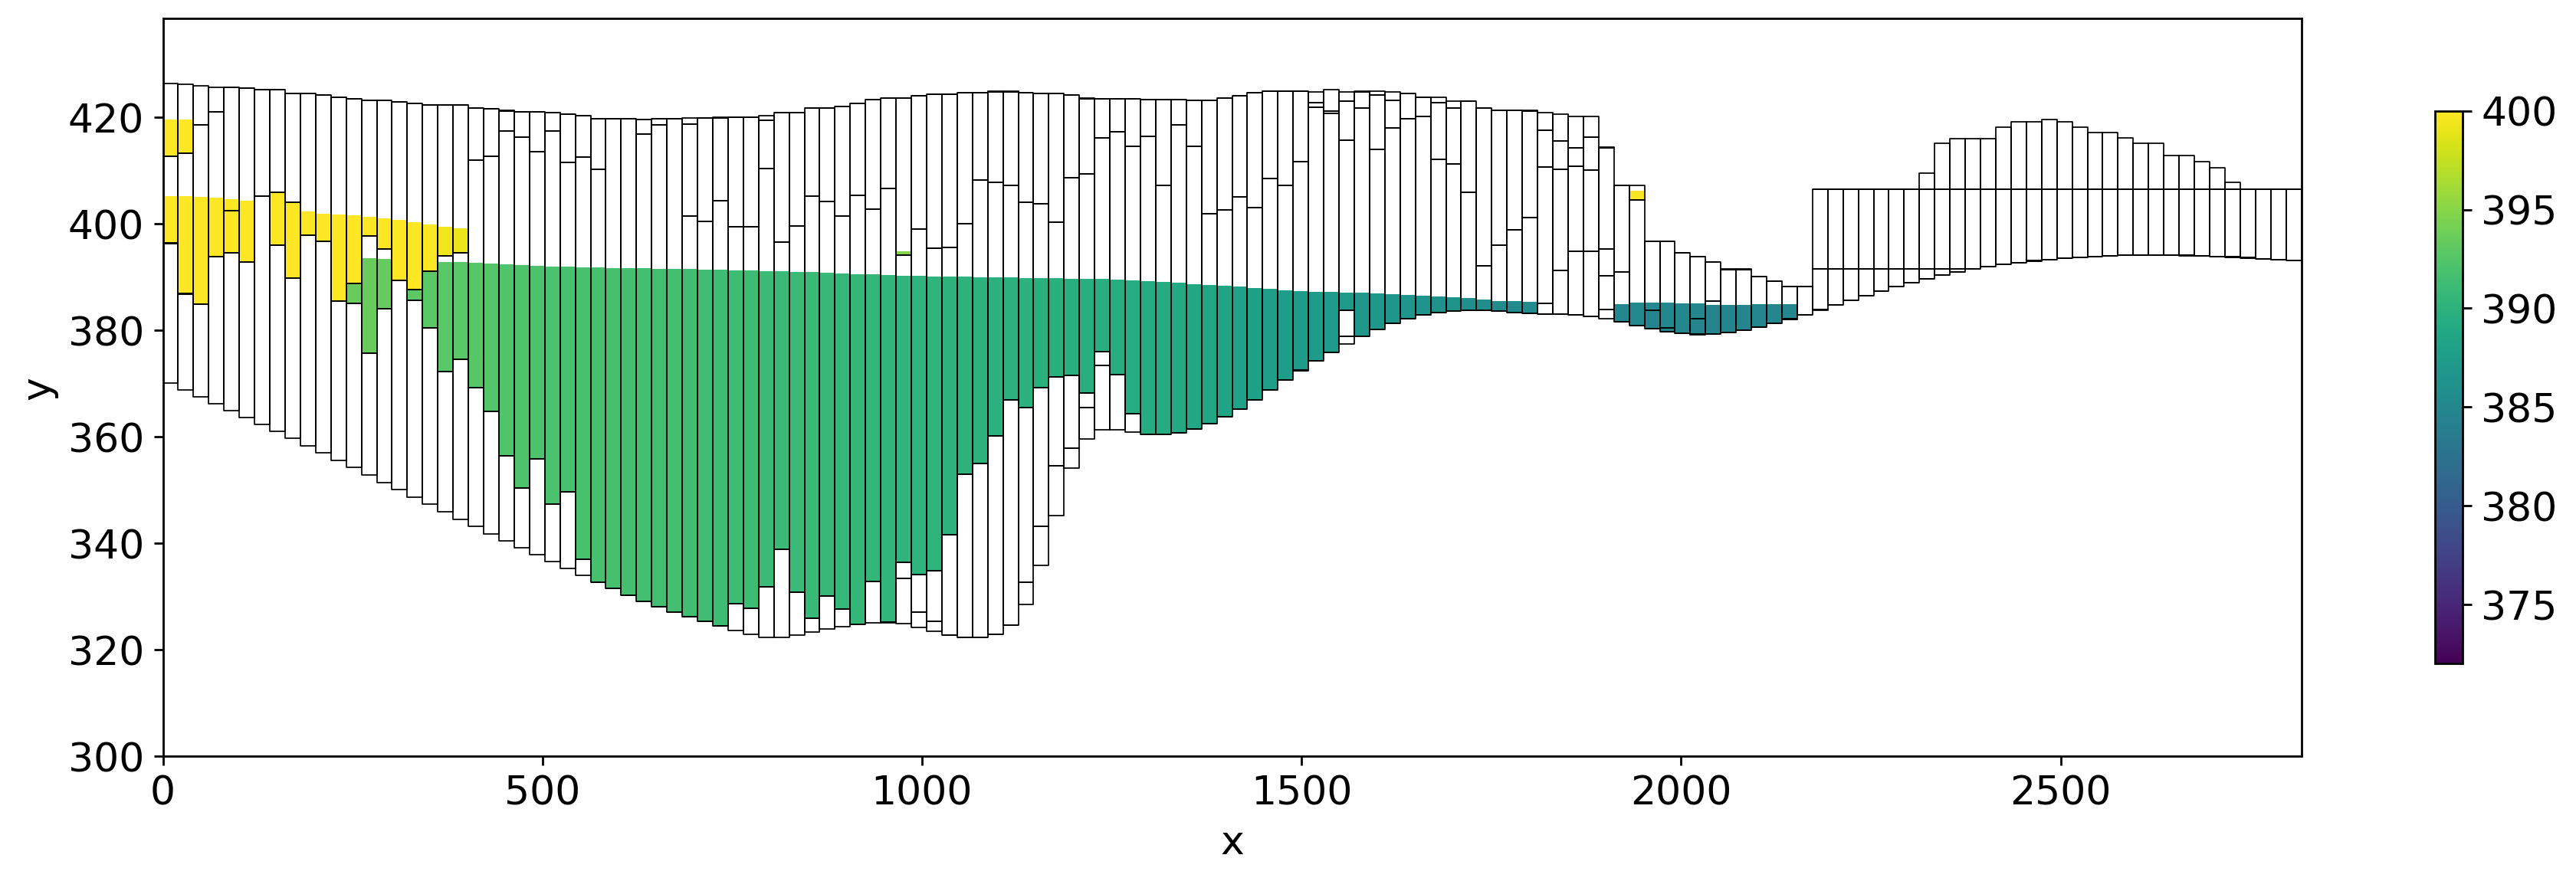

In [79]:
fig = plt.figure(figsize=(18, 5), dpi=250)
ax = fig.add_subplot(1, 1, 1)
xsect = fp.plot.PlotCrossSection(model=gwf, line={'column':75})
pc = xsect.plot_array(heads, head=heads, alpha=1, vmax=400, vmin=372)
patches = xsect.plot_ibound(head=heads)

xsect.plot_grid(linewidth=0.5, color="black")
xsect.plot_bc("CHD")
cb = plt.colorbar(pc, shrink=0.75)
plt.xlabel('x')
plt.ylabel('y')
#plt.title('Simulated Hydraulic Heads - Cross-section')
plt.show()

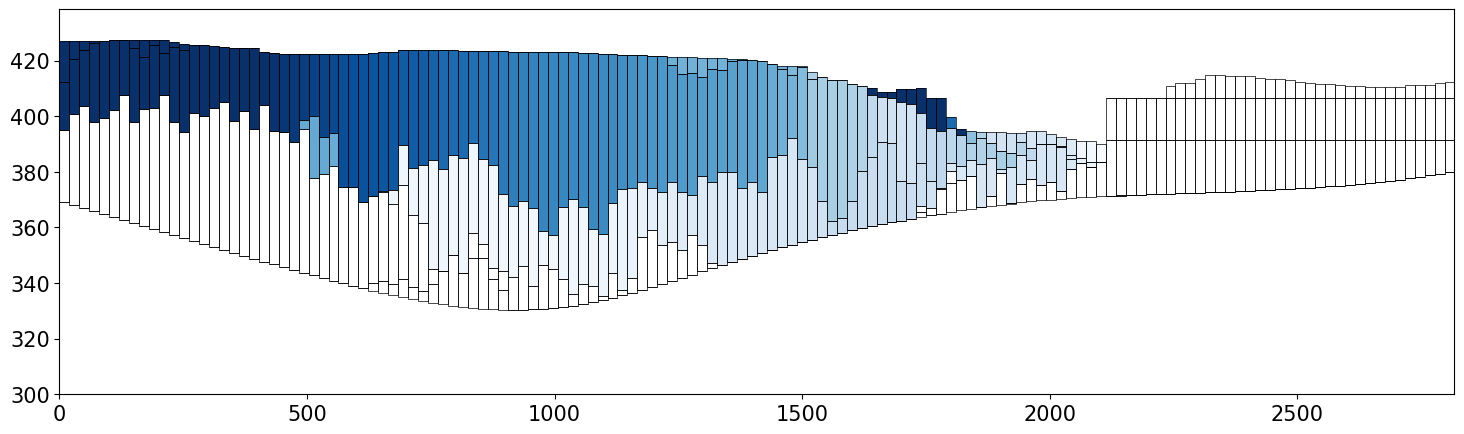

In [80]:
# plot cross section
from flopy.plot import PlotCrossSection
fig, ax = plt.subplots(1, 1, figsize=(18, 5))
cross_section = PlotCrossSection(model=gwf, line={"column": 56})
cross_section.plot_array(heads, cmap="Blues", ax=ax, vmax=400)
cross_section.plot_grid(linewidth=0.5, color="black")

In [81]:
plt.rc('font', size=10) #controls default text size
plt.rc('axes', titlesize=12) #fontsize of the title
plt.rc('axes', labelsize=12) #fontsize of the x and y labels
plt.rc('xtick', labelsize=10) #fontsize of the x tick labels
plt.rc('ytick', labelsize=10) #fontsize of the y tick labels
plt.rc('legend', fontsize=10) #fontsize of the legend

In [82]:
cobj = gwf.output.budget()
qx, qy, qz = fp.utils.postprocessing.get_specific_discharge(
        cobj.get_data(text="DATA-SPDIS", kstpkper=(0, 0))[0], gwf)

import flopy
from flopy.plot import PlotMapView

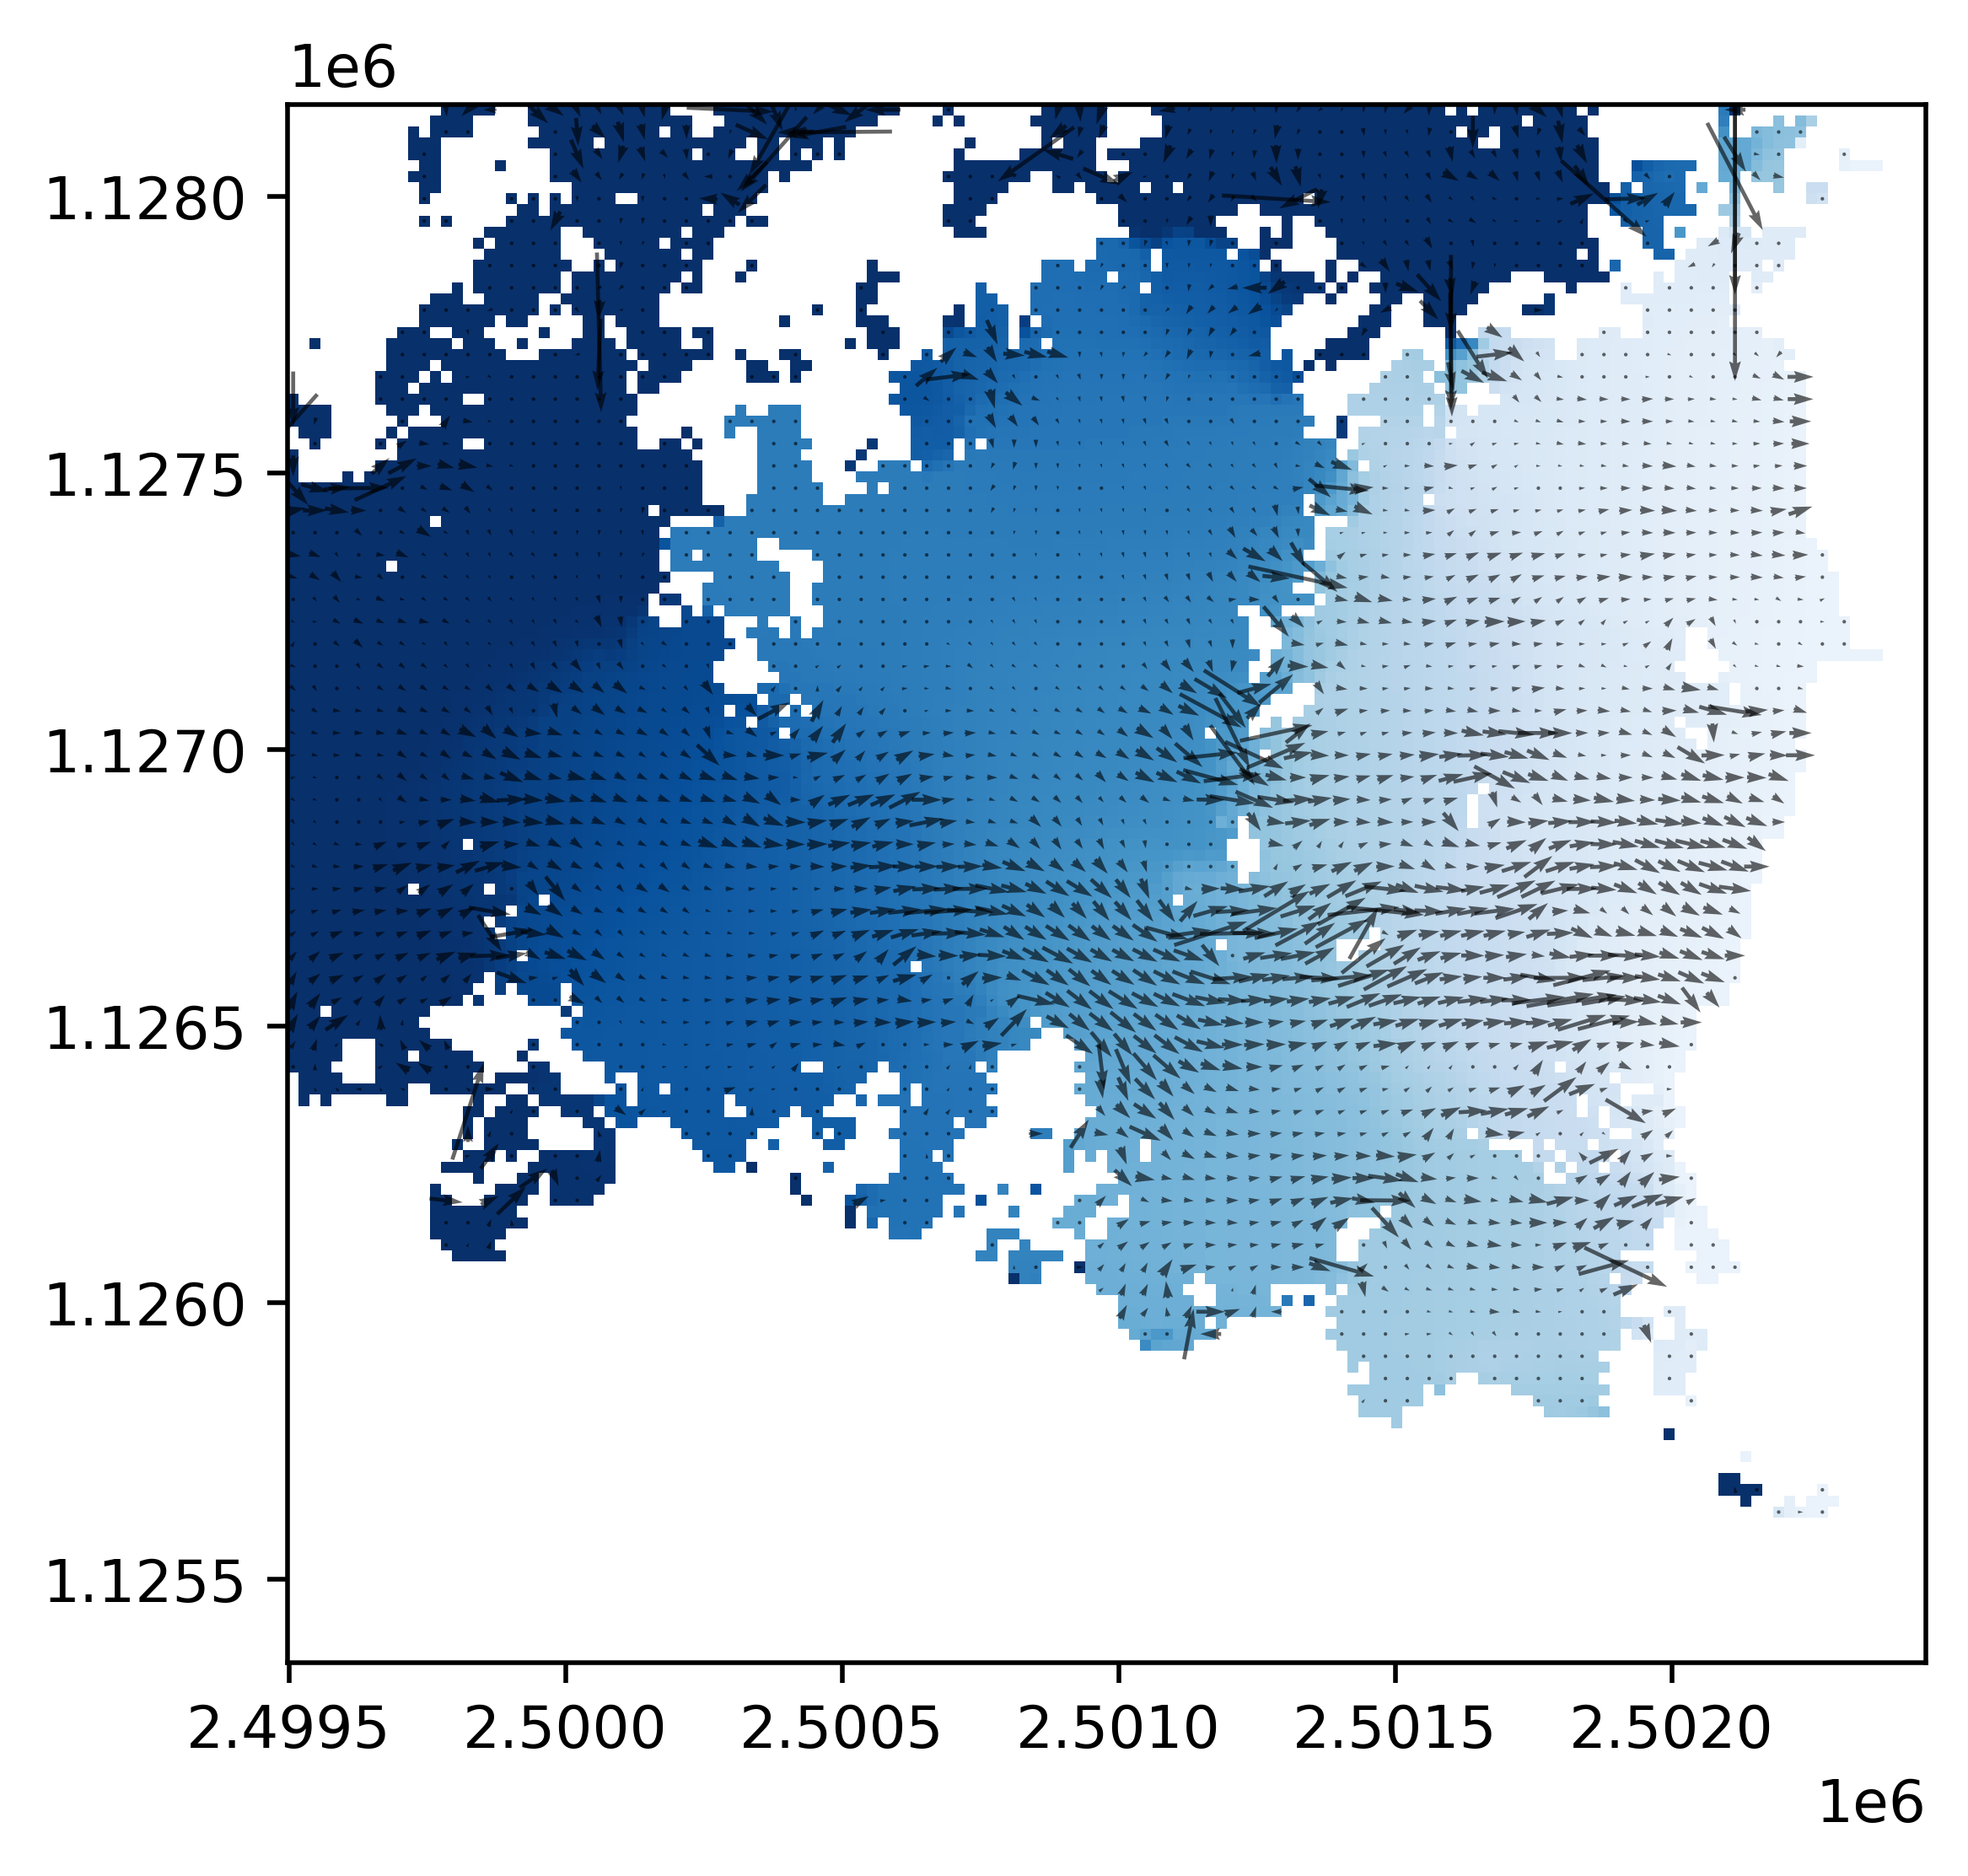

In [83]:
plt.figure(dpi=500)
mapview = PlotMapView(model=gwf, layer=2)
quadmesh = mapview.plot_array(heads, cmap="Blues",vmax=400, vmin=370)
mapview.plot_vector(qx, qy, color="black", istep=2, jstep=2, alpha=0.6)
plt.show()

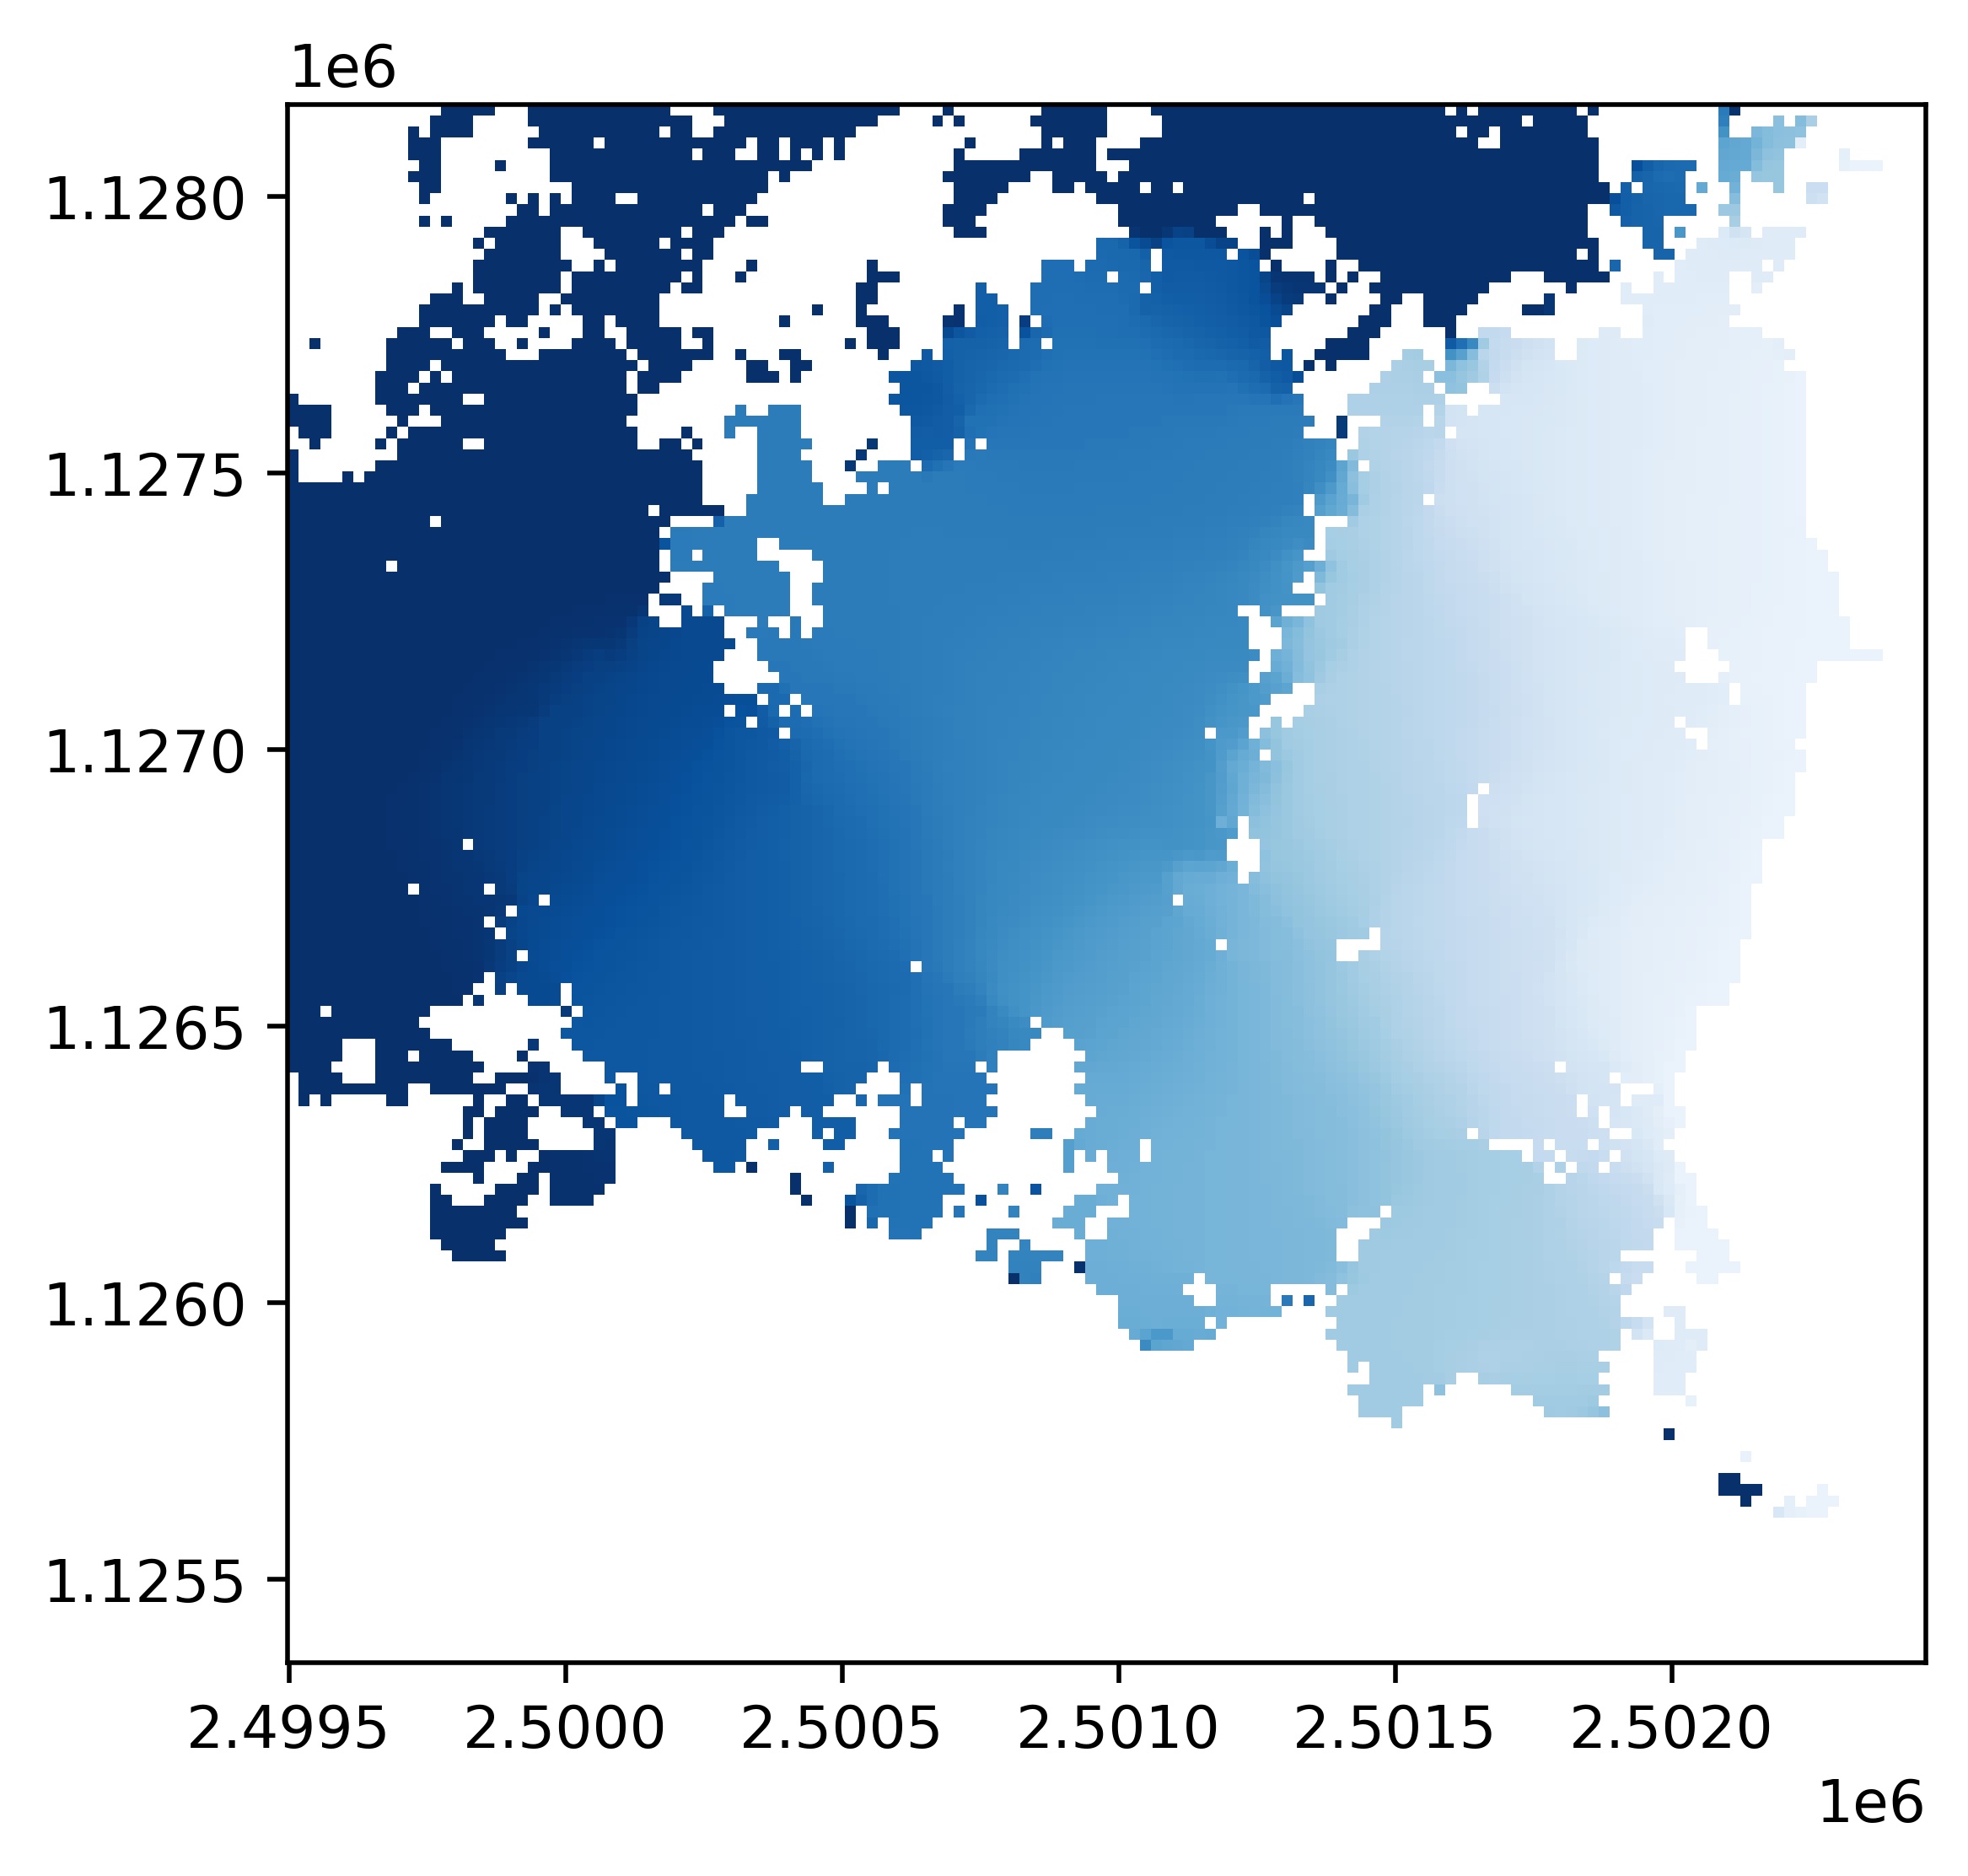

In [84]:

plt.figure(dpi=500)
mapview = PlotMapView(model=gwf, layer=2)
quadmesh = mapview.plot_array(heads, cmap="Blues",vmax=400, vmin=370)
plt.show()